In [1]:
# Оптимизация TensorFlow
import tensorflow as tf
tf.config.optimizer.set_jit(True)  # Включение XLA-компиляции
tf.config.threading.set_intra_op_parallelism_threads(8)
#tf.config.threading.set_inter_op_parallelism_threads(8)

# Для GPU
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
            #tf.config.experimental.set_memory_limit(gpu, 8192)  # Лимит 8GB
    except RuntimeError as e:
        print(e)

2025-11-06 20:17:06.169105: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-06 20:17:06.197141: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-06 20:17:06.955663: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [3]:
!pwd

/home/oleg/projects/ML/Bacterial_Colony


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("samaarashidaarbi/dibas-bacterial-colony-dataset")

print("Path to dataset files:", path)

100%|██████████████████████████████████████████████████████████████████████████████| 4.16G/4.16G [02:26<00:00, 30.4MB/s]

Extracting files...


Path to dataset files: /home/oleg/.cache/kagglehub/datasets/samaarashidaarbi/dibas-bacterial-colony-dataset/versions/1


In [ ]:
dataset_patch = '/home/oleg/.cache/kagglehub/datasets/samaarashidaarbi/dibas-bacterial-colony-dataset/versions/1'

In [6]:
# Текущая директория + путь к датасету

import os
HOME = os.getcwd()
print(HOME)
print('-----------------------')
# Пути
IMAGE_PATH = "/home/oleg/.cache/kagglehub/datasets/samaarashidaarbi/dibas-bacterial-colony-dataset/versions/1"

os.listdir(IMAGE_PATH)

/home/oleg/projects/ML/Bacterial_Colony
-----------------------


['Lactobacillus.rhamnosus',
 'Clostridium.perfringens',
 'Micrococcus.spp',
 'Lactobacillus.crispatus',
 'Veionella',
 'Streptococcus.agalactiae',
 'Enterococcus.faecalis',
 'Propionibacterium.acnes',
 'Fusobacterium',
 'Neisseria.gonorrhoeae',
 'Lactobacillus.casei',
 'Acinetobacter.baumanii',
 'Proteus',
 'Bacteroides.fragilis',
 'Lactobacillus.reuteri',
 'Actinomyces.israeli',
 'Escherichia.coli',
 'Candida.albicans',
 'Staphylococcus.saprophiticus',
 'Lactobacillus.salivarius',
 'Staphylococcus.epidermidis',
 'Lactobacillus.johnsonii',
 'Enterococcus.faecium',
 'Lactobacillus.paracasei',
 'Bifidobacterium.spp',
 'Lactobacillus.gasseri',
 'Porfyromonas.gingivalis',
 'Staphylococcus.aureus',
 'Listeria.monocytogenes',
 'Lactobacillus.plantarum',
 'Pseudomonas.aeruginosa',
 'Lactobacillus.delbrueckii',
 'Lactobacillus.jehnsenii']

In [12]:
# Конвертер в jpg
'''
import os
from PIL import Image
import shutil

def convert_tif_to_png(source_dir, target_dir):
    """Конвертирует все .tif файлы в .png"""
    if os.path.exists(target_dir):
        shutil.rmtree(target_dir)
    os.makedirs(target_dir)
    
    for class_name in os.listdir(source_dir):
        class_path = os.path.join(source_dir, class_name)
        target_class_path = os.path.join(target_dir, class_name)
        
        if os.path.isdir(class_path):
            os.makedirs(target_class_path, exist_ok=True)
            
            for file in os.listdir(class_path):
                if file.lower().endswith(('.tif', '.tiff')):
                    # Открываем .tif и сохраняем как .png
                    tif_path = os.path.join(class_path, file)
                    png_path = os.path.join(target_class_path, 
                                          file.replace('.tif', '.png').replace('.tiff', '.png'))
                    
                    try:
                        with Image.open(tif_path) as img:
                            img.save(png_path, 'PNG')
                        print(f"Converted: {file} -> {os.path.basename(png_path)}")
                    except Exception as e:
                        print(f"Error converting {file}: {e}")

# Конвертируем
SOURCE_PATH = "/home/oleg/.cache/kagglehub/datasets/samaarashidaarbi/dibas-bacterial-colony-dataset/versions/1"
TARGET_PATH = "/home/oleg/projects/ML/Bacterial_Colony/Colony_dataset"

print("🔄 Converting .tif to .png...")
convert_tif_to_png(SOURCE_PATH, TARGET_PATH)
print("✅ Conversion complete!")


'''

🔄 Converting .tif to .png...
Converted: Lactobacillus.rhamnosus_0020.tif -> Lactobacillus.rhamnosus_0020.png
Converted: Lactobacillus.rhamnosus_0008.tif -> Lactobacillus.rhamnosus_0008.png
Converted: Lactobacillus.rhamnosus_0009.tif -> Lactobacillus.rhamnosus_0009.png
Converted: Lactobacillus.rhamnosus_0010.tif -> Lactobacillus.rhamnosus_0010.png
Converted: Lactobacillus.rhamnosus_0011.tif -> Lactobacillus.rhamnosus_0011.png
Converted: Lactobacillus.rhamnosus_0014.tif -> Lactobacillus.rhamnosus_0014.png
Converted: Lactobacillus.rhamnosus_0007.tif -> Lactobacillus.rhamnosus_0007.png
Converted: Lactobacillus.rhamnosus_0016.tif -> Lactobacillus.rhamnosus_0016.png
Converted: Lactobacillus.rhamnosus_0002.tif -> Lactobacillus.rhamnosus_0002.png
Converted: Lactobacillus.rhamnosus_0015.tif -> Lactobacillus.rhamnosus_0015.png
Converted: Lactobacillus.rhamnosus_0001.tif -> Lactobacillus.rhamnosus_0001.png
Converted: Lactobacillus.rhamnosus_0006.tif -> Lactobacillus.rhamnosus_0006.png
Converted: 

/home/oleg/miniconda3/envs/tensflow/lib/python3.11/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Converted: Micrococcus.spp_0001.tif -> Micrococcus.spp_0001.png
Converted: Micrococcus.spp_0017.tif -> Micrococcus.spp_0017.png
Converted: Micrococcus.spp_0005.tif -> Micrococcus.spp_0005.png
Converted: Micrococcus.spp_0022.tif -> Micrococcus.spp_0022.png
Converted: Micrococcus.spp_0006.tif -> Micrococcus.spp_0006.png
Converted: Micrococcus.spp_0009.tif -> Micrococcus.spp_0009.png
Converted: Micrococcus.spp_0003.tif -> Micrococcus.spp_0003.png
Converted: Micrococcus.spp_0015.tif -> Micrococcus.spp_0015.png
Converted: Micrococcus.spp_0012.tif -> Micrococcus.spp_0012.png
Converted: Lactobacillus.crispatus_0010.tif -> Lactobacillus.crispatus_0010.png
Converted: Lactobacillus.crispatus_0015.tif -> Lactobacillus.crispatus_0015.png
Converted: Lactobacillus.crispatus_0019.tif -> Lactobacillus.crispatus_0019.png
Converted: Lactobacillus.crispatus_0009.tif -> Lactobacillus.crispatus_0009.png
Converted: Lactobacillus.crispatus_0012.tif -> Lactobacillus.crispatus_0012.png
Converted: Lactobacillus

In [2]:

IMAGE_PATH = "/home/oleg/projects/ML/Bacterial_Colony/Colony_dataset"

📊 АНАЛИЗ ДАТАСЕТА:
  Acinetobacter.baumanii: 20 файлов
  Actinomyces.israeli: 23 файлов
  Bacteroides.fragilis: 23 файлов
  Bifidobacterium.spp: 23 файлов
  Candida.albicans: 20 файлов
  Clostridium.perfringens: 23 файлов
  Enterococcus.faecalis: 20 файлов
  Enterococcus.faecium: 20 файлов
  Escherichia.coli: 20 файлов
  Fusobacterium: 23 файлов
  Lactobacillus.casei: 20 файлов
  Lactobacillus.crispatus: 20 файлов
  Lactobacillus.delbrueckii: 20 файлов
  Lactobacillus.gasseri: 20 файлов
  Lactobacillus.jehnsenii: 20 файлов
  Lactobacillus.johnsonii: 20 файлов
  Lactobacillus.paracasei: 20 файлов
  Lactobacillus.plantarum: 20 файлов
  Lactobacillus.reuteri: 20 файлов
  Lactobacillus.rhamnosus: 20 файлов
  Lactobacillus.salivarius: 20 файлов
  Listeria.monocytogenes: 22 файлов
  Micrococcus.spp: 21 файлов
  Neisseria.gonorrhoeae: 23 файлов
  Porfyromonas.gingivalis: 23 файлов
  Propionibacterium.acnes: 23 файлов
  Proteus: 20 файлов
  Pseudomonas.aeruginosa: 20 файлов
  Staphylococcus.au

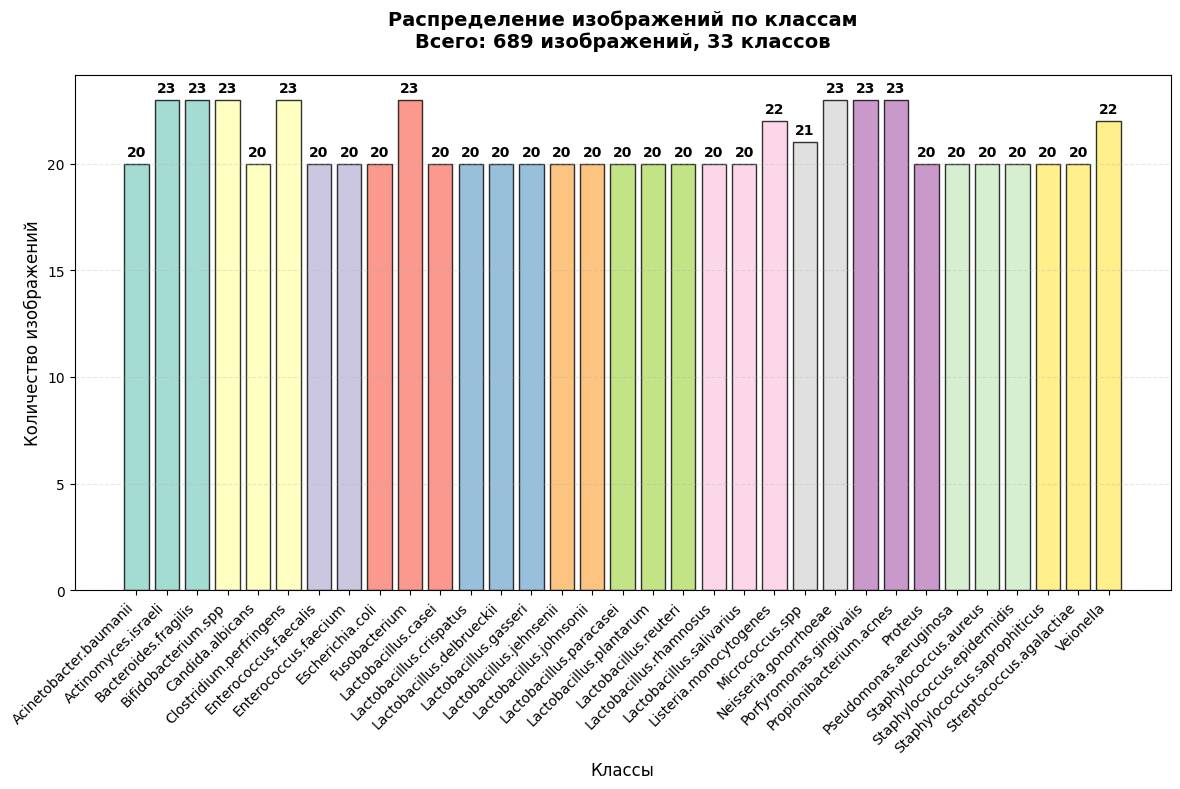

In [2]:
# Простой анализ датасета с визуализацией

import os
import matplotlib.pyplot as plt
import numpy as np

def analyze_dataset_simple(dataset_path):
    """
    Простой анализ датасета с визуализацией
    """
    # Проверяем существование пути
    if not os.path.exists(dataset_path):
        print(f"❌ Ошибка: путь '{dataset_path}' не существует")
        return None
    
    # Получаем список классов
    class_names = [d for d in os.listdir(dataset_path) 
                  if os.path.isdir(os.path.join(dataset_path, d))]
    class_names.sort()
    
    if not class_names:
        print("❌ В датасете не найдено папок с классами")
        return None
    
    # Подсчет файлов
    class_counts = {}
    total_files = 0
    
    print("📊 АНАЛИЗ ДАТАСЕТА:")
    for class_name in class_names:
        class_path = os.path.join(dataset_path, class_name)
        image_files = [f for f in os.listdir(class_path) 
                      if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', 'tif'))]
        count = len(image_files)
        class_counts[class_name] = count
        total_files += count
        print(f"  {class_name}: {count} файлов")
    
    print(f"📈 ИТОГО: {total_files} изображений, {len(class_names)} классов")
    
    # Визуализация
    plt.figure(figsize=(12, 8))
    
    classes = list(class_counts.keys())
    counts = list(class_counts.values())
    
    # Создаем диаграмму
    bars = plt.bar(classes, counts, color=plt.cm.Set3(np.linspace(0, 1, len(classes))), 
                   edgecolor='black', alpha=0.8)
    
    # Настройки графика
    plt.title(f'Распределение изображений по классам\nВсего: {total_files} изображений, {len(class_names)} классов', 
              fontsize=14, fontweight='bold', pad=20)
    plt.xlabel('Классы', fontsize=12)
    plt.ylabel('Количество изображений', fontsize=12)
    
    # Поворачиваем подписи и выравниваем
    plt.xticks(rotation=45, ha='right')
    
    # Добавляем значения на столбцы
    for bar, count in zip(bars, counts):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + max(counts)*0.01,
                f'{count}', ha='center', va='bottom', fontweight='bold', fontsize=10)
    
    # Добавляем сетку для удобства чтения
    plt.grid(True, axis='y', alpha=0.3, linestyle='--')
    
    # Настраиваем отступы
    plt.tight_layout()
    
    plt.show()
    
    return {'class_names': class_names, 'class_counts': class_counts, 'total_files': total_files}

# ИСПОЛЬЗОВАНИЕ:
# Просто вызовите функцию с путем к вашему датасету
result = analyze_dataset_simple(IMAGE_PATH)

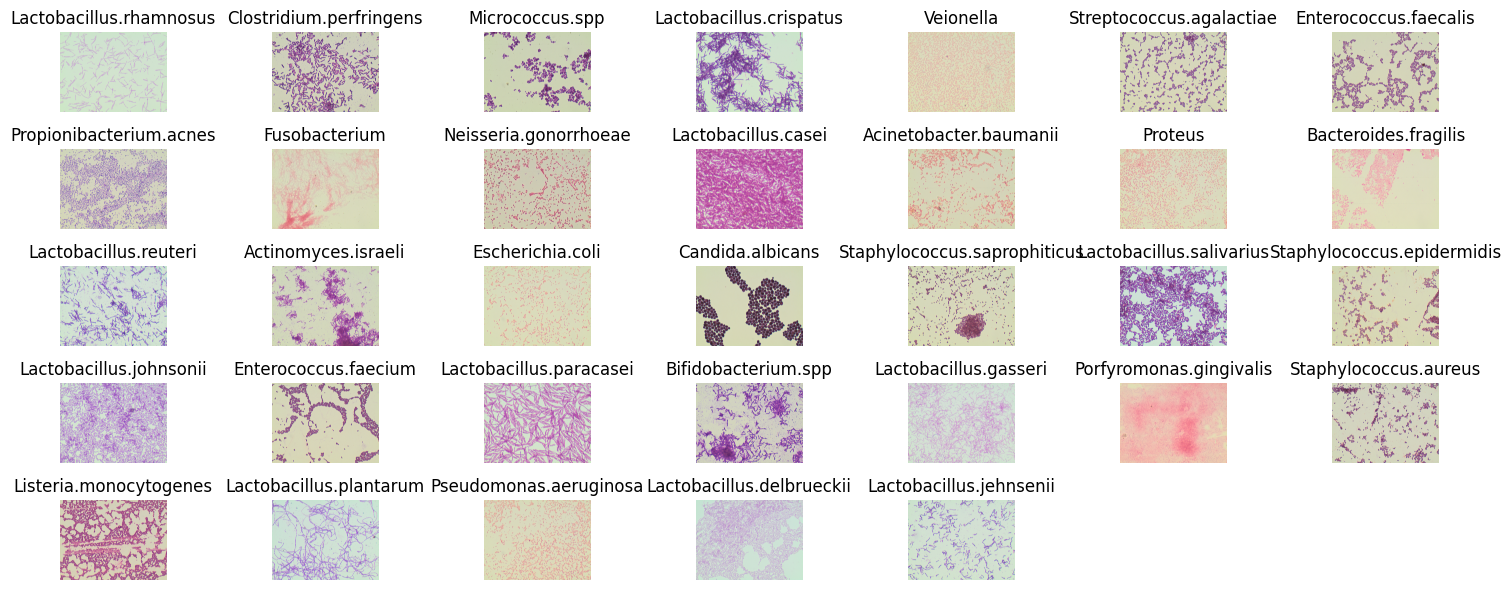

🎲 Показано по 1 случайному изображению из 33 категорий


In [3]:
# Показано по 1 случайному изображению из каждой категорий

from PIL import Image
import os
import matplotlib.pyplot as plt
import random

# Создаем график 2x5
fig, axes = plt.subplots(5, 7, figsize=(15, 6))
axes = axes.ravel()

categories = os.listdir(IMAGE_PATH)
plot_index = 0

for category in categories:
    category_path = os.path.join(IMAGE_PATH, category)
    file_names = os.listdir(category_path)
    
    # Берем 1 случайное изображение из каждой категории
    if file_names:
        random_file = random.choice(file_names)
        img_path = os.path.join(category_path, random_file)
        img = Image.open(img_path)
        
        axes[plot_index].imshow(img)
        axes[plot_index].set_title(f"{category}", fontsize=12)
        axes[plot_index].axis('off')
        plot_index += 1

# Скрываем лишние subplot'ы
for i in range(plot_index, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

print(f"🎲 Показано по 1 случайному изображению из {plot_index} категорий")

In [5]:
# МЕТКИ INTEGER

# САМЫЙ ПРОСТОЙ ВАРИАНТ - integer labels

import tensorflow as tf
#from tensorflow.keras.applications.resnet50 import preprocess_input        # импорт для resnet50
from tensorflow.keras.applications.efficientnet import preprocess_input     # импорт для efficientnet
import numpy as np
import matplotlib.pyplot as plt

#height, width = 224, 224
height, width = 640, 480
batch_size=16

print("🔄 СОЗДАЕМ ПАЙПЛАЙН...")

# Загрузка данных (хорошо!)
train_data_raw = tf.keras.preprocessing.image_dataset_from_directory(
    IMAGE_PATH,
    validation_split=0.2,
    subset='training',
    seed=42,
    image_size=(height, width),
    batch_size=batch_size,
    shuffle=True
)

validation_data_raw = tf.keras.preprocessing.image_dataset_from_directory(
    IMAGE_PATH,
    validation_split=0.2,
    subset='validation', 
    seed=42,
    image_size=(height, width),
    batch_size=batch_size,
    shuffle=True
)

# Проверка формата (хорошо!)
images, labels = next(iter(train_data_raw))
print(f"Labels shape: {labels.shape}")  # (32,) - integer
print(f"Labels: {labels.numpy()[:15]}")  # [0, 1, 0, 2, 1]

class_names = train_data_raw.class_names
num_classes = len(class_names)
print(f"🏷️ Классы: {class_names}")


# ЗАМЕНИТЕ аугментацию на эту:
# data_augmentation = tf.keras.Sequential([
#     tf.keras.layers.RandomFlip("horizontal_and_vertical"),
#     tf.keras.layers.RandomRotation(0.4),  # Увеличьте с 0.3
#     tf.keras.layers.RandomZoom(0.4),      # Увеличьте с 0.3
#     tf.keras.layers.RandomContrast(0.4),  # Увеличьте с 0.3
#     tf.keras.layers.RandomBrightness(0.4), # Увеличьте с 0.3
#     tf.keras.layers.RandomTranslation(0.3, 0.3), # Увеличьте с 0.2
    
#     # ДОБАВЬТЕ эти слои:
#     tf.keras.layers.GaussianNoise(0.15),    # Шум для регуляризации
#     tf.keras.layers.RandomShear(0.3),       # Наклон изображения
# ])

print("🔄 Усиленная аугментация применена")

# Аугментация (хорошо!)
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.4),  # Контраст до 40%
    tf.keras.layers.RandomBrightness(0.3), # Яркость до 30%
    tf.keras.layers.RandomTranslation(0.2, 0.2),  # Сдвиг до 20%  
])

#print("🔧 СОЗДАЕМ ПРОСТОЙ ПАЙПЛАЙН...")

'''
# Проепроцессин для RESNET
def preprocess_and_augment(image, label, training=False):
    """Preprocess + аугментация если training=True"""
    image = preprocess_input(tf.cast(image, tf.float32))
    if training:
        image = data_augmentation(image, training=True)
    return image, label
'''

# Проепроцессин для EfficientNet
def preprocess_and_augment(image, label, training=False):
    """Правильный препроцессинг для EfficientNet"""
    image = tf.cast(image, tf.float32)
    image = preprocess_input(image)  # ✅ Должен нормализовать в [0, 1] или [-1, 1]
    if training:
        image = data_augmentation(image, training=True)
    return image, label

# Финальные datasets за 2 шага
train_data = (
    train_data_raw
    .map(lambda x, y: preprocess_and_augment(x, y, training=True),
         num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)

validation_data = (
    validation_data_raw
    .map(lambda x, y: preprocess_and_augment(x, y, training=False), 
         num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)

# Убедимся что препроцессинг работает правильно
print("🔍 Проверка препроцессинга:")
for images, labels in train_data.take(1):
    print(f"Shape: {images.shape}")
    print(f"Data range: {tf.reduce_min(images):.3f} to {tf.reduce_max(images):.3f}")
    print(f"Mean: {tf.reduce_mean(images):.3f}")
    break

print("✅ Пайплайн создан!")

🔄 СОЗДАЕМ ПАЙПЛАЙН...
Found 689 files belonging to 33 classes.
Using 552 files for training.
Found 689 files belonging to 33 classes.
Using 137 files for validation.
Labels shape: (16,)
Labels: [ 3  3 11  5 15  1 11 30 28 17  9 29  3  6  2]
🏷️ Классы: ['Acinetobacter.baumanii', 'Actinomyces.israeli', 'Bacteroides.fragilis', 'Bifidobacterium.spp', 'Candida.albicans', 'Clostridium.perfringens', 'Enterococcus.faecalis', 'Enterococcus.faecium', 'Escherichia.coli', 'Fusobacterium', 'Lactobacillus.casei', 'Lactobacillus.crispatus', 'Lactobacillus.delbrueckii', 'Lactobacillus.gasseri', 'Lactobacillus.jehnsenii', 'Lactobacillus.johnsonii', 'Lactobacillus.paracasei', 'Lactobacillus.plantarum', 'Lactobacillus.reuteri', 'Lactobacillus.rhamnosus', 'Lactobacillus.salivarius', 'Listeria.monocytogenes', 'Micrococcus.spp', 'Neisseria.gonorrhoeae', 'Porfyromonas.gingivalis', 'Propionibacterium.acnes', 'Proteus', 'Pseudomonas.aeruginosa', 'Staphylococcus.aureus', 'Staphylococcus.epidermidis', 'Staphyloc

In [7]:
# МЕТКИ INTEGER - ИСПРАВЛЕННАЯ ВЕРСИЯ ДЛЯ CUDA

import tensorflow as tf
from tensorflow.keras.applications.efficientnet import preprocess_input
import numpy as np
import matplotlib.pyplot as plt

# Принудительно включаем GPU
physical_devices = tf.config.list_physical_devices('GPU')
if physical_devices:
    tf.config.experimental.set_memory_growth(physical_devices[0], True)
    print("✅ GPU активирован")
else:
    print("❌ GPU не найден")

# height, width = 224, 224
height, width = 640, 480
batch_size = 16  # ⬅️ Уменьшаем для стабильности

print("🔄 СОЗДАЕМ ПАЙПЛАЙН ДЛЯ CUDA...")

# Загрузка данных
train_data_raw = tf.keras.preprocessing.image_dataset_from_directory(
    IMAGE_PATH,
    validation_split=0.2,
    subset='training',
    seed=42,
    image_size=(height, width),
    batch_size=batch_size,
    shuffle=True
)

validation_data_raw = tf.keras.preprocessing.image_dataset_from_directory(
    IMAGE_PATH,
    validation_split=0.2,
    subset='validation', 
    seed=42,
    image_size=(height, width),
    batch_size=batch_size,
    shuffle=True
)

# Проверка данных
images, labels = next(iter(train_data_raw))
print(f"✅ Labels shape: {labels.shape}")
print(f"✅ Labels: {labels.numpy()[:10]}")

class_names = train_data_raw.class_names
num_classes = len(class_names)
print(f"🏷️ Классы: {class_names}")
print(f"🔢 Количество классов: {num_classes}")

# ЗАМЕНИТЕ аугментацию на эту:
# data_augmentation = tf.keras.Sequential([
#     tf.keras.layers.RandomFlip("horizontal_and_vertical"),
#     tf.keras.layers.RandomRotation(0.4),  # Увеличьте с 0.3
#     tf.keras.layers.RandomZoom(0.4),      # Увеличьте с 0.3
#     tf.keras.layers.RandomContrast(0.4),  # Увеличьте с 0.3
#     tf.keras.layers.RandomBrightness(0.4), # Увеличьте с 0.3
#     tf.keras.layers.RandomTranslation(0.3, 0.3), # Увеличьте с 0.2
    
#     # ДОБАВЬТЕ эти слои:
#     tf.keras.layers.GaussianNoise(0.15),    # Шум для регуляризации
#     tf.keras.layers.RandomShear(0.3),       # Наклон изображения
# ])

print("🔄 Усиленная аугментация применена")


# ПРАВИЛЬНАЯ аугментация - ДО препроцессинга!
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.3),  # 10%
    tf.keras.layers.RandomZoom(0.3),      # 10%
    tf.keras.layers.RandomContrast(0.3),  # 20%
    tf.keras.layers.RandomBrightness(0.3), # 20%
    tf.keras.layers.RandomTranslation(0.2, 0.2),  # 20% - СИЛЬНАЯ
])

# ⚠️ ИСПРАВЛЕННЫЙ препроцессинг
def preprocess_and_augment(image, label, training=False):
    """Правильный порядок: аугментация -> препроцессинг"""
    
    # 1. Сначала приводим к float32
    image = tf.cast(image, tf.float32)
    
    # 2. Аугментация ТОЛЬКО если тренировка
    if training:
        image = data_augmentation(image, training=True)
    
    # 3. Препроцессинг ВСЕГДА (после аугментации!)
    image = preprocess_input(image)
    #image = image / 255.0 # добавил нормализацию
    
    return image, label

# Создаем datasets
train_data = (
    train_data_raw
    .map(lambda x, y: preprocess_and_augment(x, y, training=True),
         num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)

validation_data = (
    validation_data_raw
    .map(lambda x, y: preprocess_and_augment(x, y, training=False), 
         num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)

# Проверка правильности препроцессинга
print("🔍 Проверка препроцессинга:")
for images, labels in train_data.take(1):
    print(f"✅ Shape: {images.shape}")
    print(f"✅ Data range: {tf.reduce_min(images):.3f} to {tf.reduce_max(images):.3f}")
    print(f"✅ Mean: {tf.reduce_mean(images):.3f}")
    print(f"✅ Стандартное отклонение: {tf.math.reduce_std(images):.3f}")
    break

print("✅ Пайплайн создан для CUDA!")

✅ GPU активирован
🔄 СОЗДАЕМ ПАЙПЛАЙН ДЛЯ CUDA...
Found 689 files belonging to 33 classes.
Using 552 files for training.
Found 689 files belonging to 33 classes.
Using 137 files for validation.
✅ Labels shape: (16,)
✅ Labels: [ 3  3 11  5 15  1 11 30 28 17]
🏷️ Классы: ['Acinetobacter.baumanii', 'Actinomyces.israeli', 'Bacteroides.fragilis', 'Bifidobacterium.spp', 'Candida.albicans', 'Clostridium.perfringens', 'Enterococcus.faecalis', 'Enterococcus.faecium', 'Escherichia.coli', 'Fusobacterium', 'Lactobacillus.casei', 'Lactobacillus.crispatus', 'Lactobacillus.delbrueckii', 'Lactobacillus.gasseri', 'Lactobacillus.jehnsenii', 'Lactobacillus.johnsonii', 'Lactobacillus.paracasei', 'Lactobacillus.plantarum', 'Lactobacillus.reuteri', 'Lactobacillus.rhamnosus', 'Lactobacillus.salivarius', 'Listeria.monocytogenes', 'Micrococcus.spp', 'Neisseria.gonorrhoeae', 'Porfyromonas.gingivalis', 'Propionibacterium.acnes', 'Proteus', 'Pseudomonas.aeruginosa', 'Staphylococcus.aureus', 'Staphylococcus.epidermi

2025-11-06 20:17:57.035811: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 1092433383437229844
2025-11-06 20:17:57.036033: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 11663609407063450104
2025-11-06 20:17:57.036071: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 7147294448336970706
2025-11-06 20:17:57.036085: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 12457642037025562797
2025-11-06 20:17:57.036111: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 18203404960063947964
2025-11-06 20:17:57.036115: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 17405810828096305654
2025-11-06 20:17:57.036120: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv

✅ Пайплайн создан для CUDA!


In [16]:
import gc
import tensorflow as tf

# 🔄 ПОЛНАЯ ОЧИСТКА
tf.keras.backend.clear_session()
gc.collect()

0

✅ Модель создана для 33 классов!
✅ Transfer Learning модель готова!
🎯 EfficientNetV2S заморожена, обучаться будут только добавленные Dense слои


Model: "functional_14"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_27      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetv2-s    │ (None, 7, 7,      │ 20,331,360 │ input_layer_27[0… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ efficientnetv2-s… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 1280)      │          0 │ efficientnetv2-s… │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_13      │ (None, 2560)      │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 2560)      │     10,240 │ concatenate_13[0… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_84 (Dense)    │ (None, 512)       │  1,311,232 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ dense_84[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_38       │ (None, 512)       │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_85 (Dense)    │ (None, 512)       │  1,311,232 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_38          │ (None, 512)       │          0 │ activation_38[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_38 (Add)        │ (None, 512)       │          0 │ dense_85[0][0],   │
│                     │                   │            │ dropout_38[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_86 (Dense)    │ (None, 256)       │    131,328 │ add_38[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_86[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_39       │ (None, 256)       │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_87 (Dense)    │ (None, 256)       │    131,328 │ add_38[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_39          │ (None, 256)       │          0 │ activation_39[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_39 (Add)        │ (None, 256)       │          0 │ dense_87[0][0],   │
│                     │                   │            │ dropout_39[0][0]

 Total params: 23,300,353 (88.88 MB)

 Trainable params: 2,962,081 (11.30 MB)

 Non-trainable params: 20,338,272 (77.58 MB)

Epoch 1/90
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 500ms/step - accuracy: 0.1816 - loss: 9.3008
Epoch 1: val_accuracy improved from None to 0.33577, saving model to ./keras_lab/EfficientNetV2S/keras_EfficientNetV2S_temp.keras
35/35 ━━━━━━━━━━━━━━━━━━━━ 57s 874ms/step - accuracy: 0.2935 - loss: 8.0387 - val_accuracy: 0.3358 - val_loss: 12.8434 - learning_rate: 0.0010
Epoch 2/90
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.5156 - loss: 4.7042
Epoch 2: val_accuracy improved from 0.33577 to 0.49635, saving model to ./keras_lab/EfficientNetV2S/keras_EfficientNetV2S_temp.keras
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 107ms/step - accuracy: 0.5145 - loss: 5.0512 - val_accuracy: 0.4964 - val_loss: 6.1268 - learning_rate: 0.0010
Epoch 3/90
33/35 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.5778 - loss: 4.3599
Epoch 3: val_accuracy improved from 0.49635 to 0.62774, saving model to ./keras_lab/EfficientNetV2S/keras_EfficientNetV2S_temp.keras
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - accuracy: 0.5996 - los

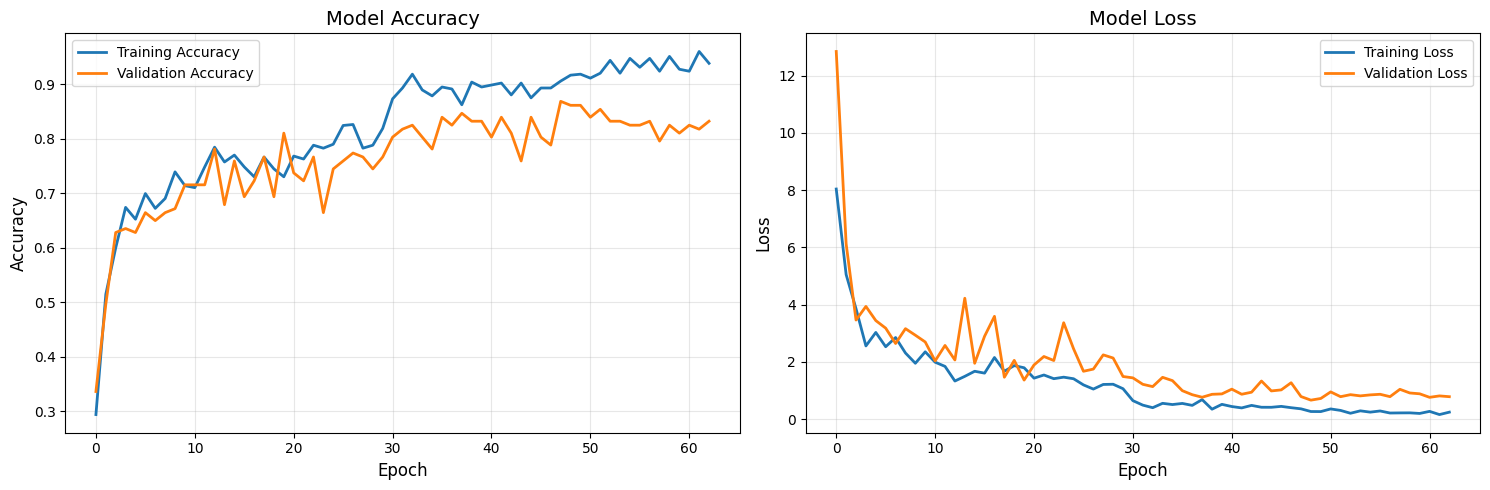

In [22]:
# MIDDLE_1

# Комбинированный Pooling + Residual connection

from tensorflow.keras.layers import GlobalAveragePooling2D, GlobalMaxPooling2D, Concatenate, Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras.regularizers import l1, l2, l1_l2

model_name = 'EfficientNetV2S' # {model_name}
alias = '_middle_5_' # {_middle_}
#val_accuracy=0



# Создание модели
import tensorflow as tf
from tensorflow.keras.applications import ResNet50, EfficientNetB0, EfficientNetV2B0, EfficientNetV2S
from tensorflow.keras import layers, Model

# Словарь моделей
MODELS = {
    'EfficientNetV2S': EfficientNetV2S,
    'EfficientNetV2B0': EfficientNetV2B0,
    'EfficientNetB0': EfficientNetB0,
    'ResNet50': ResNet50
}
'''
def dense_block(x, units, dropout_rate=0.5, l2_reg=1e-4):
    x = Dense(units, kernel_regularizer=l2(l2_reg))(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(dropout_rate)(x)
    return x
'''

# Используйте готовую функцию чтобы не думать о проекции
def residual_block(x, units, dropout_rate=0.5, l2_reg=1e-5):
    identity = x
    x = Dense(units, kernel_regularizer=l2(l2_reg))(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(dropout_rate)(x)
    
    if identity.shape[-1] != units:
        identity = Dense(units, kernel_regularizer=l2(l2_reg))(identity)
    
    return layers.Add()([identity, x])

height, width = 224, 224
#num_classes = 8  # ⬅️ ДОБАВЬТЕ ЭТУ СТРОКУ!

# 1. Сначала создаем inputs
inputs = tf.keras.Input(shape=(height, width, 3))  # ⬅️ ПЕРВЫМ ДЕЛОМ!

# 2. Базовая модель
base_model = MODELS[model_name](
    weights='imagenet',      # ✅ Предобученные веса
    include_top=False,       # ✅ Убираем старый классификатор
    input_shape=(height, width, 3)  # ⬅️ ИСПРАВЛЕНО: передаем кортеж, не переменную inputs
)
base_model.trainable = False # ✅ Замораживаем веса
x = base_model(inputs, training=False)  # ✅ BatchNorm в inference режиме

# 4. Классификатор (ваш лучший вариант)
gap = GlobalAveragePooling2D()(x)
gmp = GlobalMaxPooling2D()(x)
x = Concatenate()([gap, gmp])  # Удваиваем features
x = BatchNormalization()(x)

# Классификатор (Residual блоки вместо обычных)
x = residual_block(x, 512, dropout_rate=0.6, l2_reg=1e-5)
x = residual_block(x, 256, dropout_rate=0.5, l2_reg=1e-5) 
x = residual_block(x, 128, dropout_rate=0.4, l2_reg=1e-5)
#x = Dense(64, activation='relu')(x) # Финальная адаптация признаков
#x = Dropout(0.2)(x) # Минимальная регуляризация перед выходом
# 5. Выходной слой
outputs = layers.Dense(num_classes, activation='softmax')(x)

# 6. Сборка и компиляция
model = Model(inputs, outputs)
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # ✅ Для integer labels
    metrics=['accuracy']
)

print("✅ Модель создана для {} классов!".format(num_classes))
print("✅ Transfer Learning модель готова!")
print(f"🎯 {model_name} заморожена, обучаться будут только добавленные Dense слои")
model.summary()


import datetime
import os
import time
# ДОБАВЬТЕ ЭТО В САМОЕ НАЧАЛО СКРИПТА
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # 0=все, 1=INFO, 2=WARNING, 3=ERROR
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
tf.get_logger().setLevel('ERROR')
tf.autograph.set_verbosity(0)

from tensorflow.keras.callbacks import TensorBoard, EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# 2. Создаем callback
callbacks = [
    #EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True, verbose=1), # monitor='val_loss',  # ⬅️ Следим за loss (может быть стабильнее)
    ModelCheckpoint(f'./keras_lab/{model_name}/keras_{model_name}_temp.keras', monitor='val_accuracy', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', patience=9, factor=0.5, verbose=1),
    #tensorboard_callback
]

start_time = time.time()
# 4. Запускаем обучение
history = model.fit(
    train_data,
    epochs=90,
    validation_data=validation_data,
    callbacks=callbacks,
    verbose=1
)
# ВРЕМЯ
end_time = time.time()
training_time_seconds = end_time - start_time
hours = int(training_time_seconds // 3600)
minutes = int((training_time_seconds % 3600) // 60)
seconds = int(training_time_seconds % 60)
print(f"⏰ Время обучения: {hours:02d}:{minutes:02d}:{seconds:02d} (ч:м:с)")

# Оценка на валидационном датасете

best_model = tf.keras.models.load_model(f'./keras_lab/{model_name}/keras_{model_name}_temp.keras')
print(f"\n📊 ОЦЕНКА {model_name}{alias} НА ВАЛИДАЦИОННЫХ ДАННЫХ...")
val_results = best_model.evaluate(validation_data, verbose=1)
val_loss, val_accuracy = val_results

#print(f"✅ Финальная точность на валидации: {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")
#print(f"✅ Финальные потери на валидации: {val_loss:.4f}")

# Сохранение с точностью в названии
accuracy_percent = val_accuracy * 100
save_path = f'./keras_lab/{model_name}/keras_{model_name}{alias}{accuracy_percent:.2f}.keras'

best_model.save(save_path)
print(f"💾 Модель сохранена как: {save_path}")

# Визуализация результатов
import matplotlib.pyplot as plt
import numpy as np

def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # График точности
    ax1.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
    ax1.set_title('Model Accuracy', fontsize=14)
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Accuracy', fontsize=12)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # График потерь
    ax2.plot(history.history['loss'], label='Training Loss', linewidth=2)
    ax2.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    ax2.set_title('Model Loss', fontsize=14)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Loss', fontsize=12)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Построим графики
plot_training_history(history)




✅ Модель создана для 33 классов!
✅ Transfer Learning модель готова!
🎯 EfficientNetV2S заморожена, обучаться будут только добавленные Dense слои


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetv2-s    │ (None, 7, 7,      │ 20,331,360 │ input_layer_2[0]… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ efficientnetv2-s… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 1280)      │          0 │ efficientnetv2-s… │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 2560)      │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 2560)      │     10,240 │ concatenate_1[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 1024)      │  2,622,464 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1024)      │      4,096 │ dense_7[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 1024)      │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 1024)      │  2,622,464 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 1024)      │          0 │ activation_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 1024)      │          0 │ dense_8[0][0],    │
│                     │                   │            │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 512)       │    524,800 │ add_3[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ dense_9[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 512)       │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 512)       │    524,800 │ add_3[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 512)       │          0 │ activation_4[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 512)       │          0 │ dense_10[0][0],   │
│                     │                   │            │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 256)       │    131,328 │ add_4[0][0]     

 Total params: 26,914,433 (102.67 MB)

 Trainable params: 6,574,369 (25.08 MB)

 Non-trainable params: 20,340,064 (77.59 MB)

Epoch 1/90
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 457ms/step - accuracy: 0.2227 - loss: 13.4873
Epoch 1: val_accuracy improved from None to 0.34307, saving model to ./keras_lab/EfficientNetV2S/keras_EfficientNetV2S_temp.keras
35/35 ━━━━━━━━━━━━━━━━━━━━ 51s 794ms/step - accuracy: 0.3279 - loss: 11.8819 - val_accuracy: 0.3431 - val_loss: 17.8172 - learning_rate: 0.0010
Epoch 2/90
33/35 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.5345 - loss: 7.5116
Epoch 2: val_accuracy improved from 0.34307 to 0.43796, saving model to ./keras_lab/EfficientNetV2S/keras_EfficientNetV2S_temp.keras
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 91ms/step - accuracy: 0.5634 - loss: 7.0566 - val_accuracy: 0.4380 - val_loss: 18.2970 - learning_rate: 0.0010
Epoch 3/90
34/35 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.6548 - loss: 5.7530
Epoch 3: val_accuracy improved from 0.43796 to 0.54745, saving model to ./keras_lab/EfficientNetV2S/keras_EfficientNetV2S_temp.keras
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - accuracy: 0.6612 - l

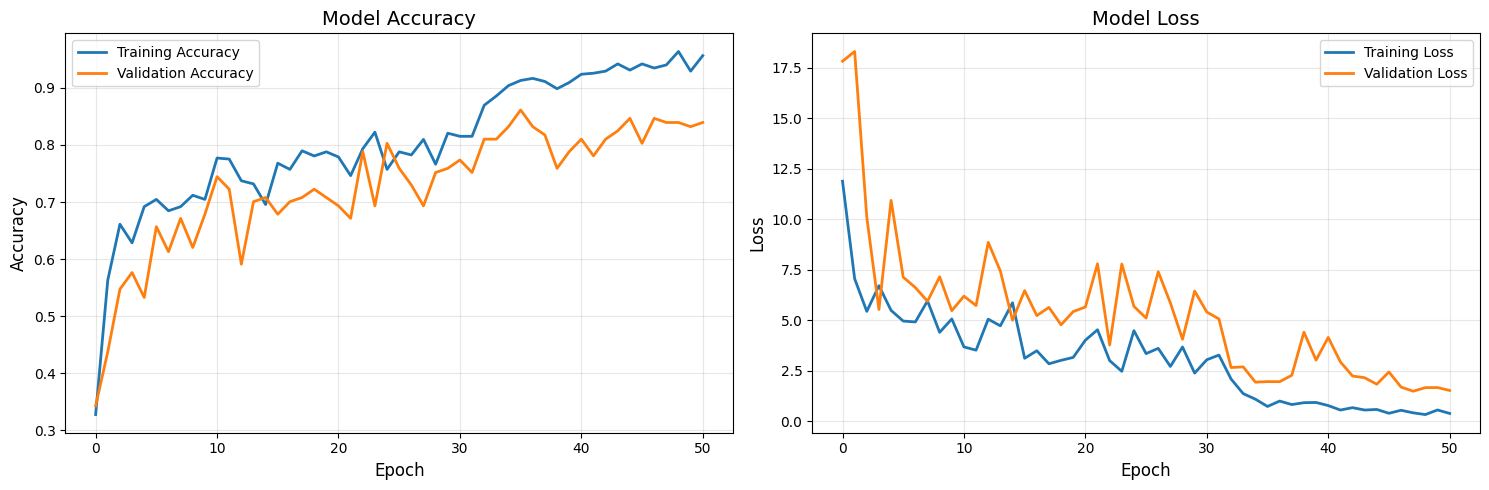

In [9]:
# MIDDLE_2

# Комбинированный Pooling + Residual connection

from tensorflow.keras.layers import GlobalAveragePooling2D, GlobalMaxPooling2D, Concatenate, Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras.regularizers import l1, l2, l1_l2

model_name = 'EfficientNetV2S' # {model_name}
alias = '_middle_2_' # {_middle_}
#val_accuracy=0



# Создание модели
import tensorflow as tf
from tensorflow.keras.applications import ResNet50, EfficientNetB0, EfficientNetV2B0, EfficientNetV2S
from tensorflow.keras import layers, Model

# Словарь моделей
MODELS = {
    'EfficientNetV2S': EfficientNetV2S,
    'EfficientNetV2B0': EfficientNetV2B0,
    'EfficientNetB0': EfficientNetB0,
    'ResNet50': ResNet50
}
'''
def dense_block(x, units, dropout_rate=0.5, l2_reg=1e-4):
    x = Dense(units, kernel_regularizer=l2(l2_reg))(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(dropout_rate)(x)
    return x
'''

# Используйте готовую функцию чтобы не думать о проекции
def residual_block(x, units, dropout_rate=0.5, l2_reg=1e-5):
    identity = x
    x = Dense(units, kernel_regularizer=l2(l2_reg))(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(dropout_rate)(x)
    
    if identity.shape[-1] != units:
        identity = Dense(units, kernel_regularizer=l2(l2_reg))(identity)
    
    return layers.Add()([identity, x])

height, width = 224, 224
#num_classes = 8  # ⬅️ ДОБАВЬТЕ ЭТУ СТРОКУ!

# 1. Сначала создаем inputs
inputs = tf.keras.Input(shape=(height, width, 3))  # ⬅️ ПЕРВЫМ ДЕЛОМ!

# 2. Базовая модель
base_model = MODELS[model_name](
    weights='imagenet',      # ✅ Предобученные веса
    include_top=False,       # ✅ Убираем старый классификатор
    input_shape=(height, width, 3)  # ⬅️ ИСПРАВЛЕНО: передаем кортеж, не переменную inputs
)
base_model.trainable = False # ✅ Замораживаем веса
x = base_model(inputs, training=False)  # ✅ BatchNorm в inference режиме

# 4. Классификатор (ваш лучший вариант)
gap = GlobalAveragePooling2D()(x)
gmp = GlobalMaxPooling2D()(x)
x = Concatenate()([gap, gmp])  # Удваиваем features
x = BatchNormalization()(x)

# Классификатор (Residual блоки вместо обычных)
x = residual_block(x, 1024, dropout_rate=0.6, l2_reg=1e-5)
x = residual_block(x, 512, dropout_rate=0.5, l2_reg=1e-5) 
x = residual_block(x, 256, dropout_rate=0.4, l2_reg=1e-5)
#x = Dense(64, activation='relu')(x) # Финальная адаптация признаков
#x = Dropout(0.2)(x) # Минимальная регуляризация перед выходом
# 5. Выходной слой
outputs = layers.Dense(num_classes, activation='softmax')(x)

# 6. Сборка и компиляция
model = Model(inputs, outputs)
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # ✅ Для integer labels
    metrics=['accuracy']
)

print("✅ Модель создана для {} классов!".format(num_classes))
print("✅ Transfer Learning модель готова!")
print(f"🎯 {model_name} заморожена, обучаться будут только добавленные Dense слои")
model.summary()


import datetime
import os
import time
# ДОБАВЬТЕ ЭТО В САМОЕ НАЧАЛО СКРИПТА
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # 0=все, 1=INFO, 2=WARNING, 3=ERROR
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
tf.get_logger().setLevel('ERROR')
tf.autograph.set_verbosity(0)

from tensorflow.keras.callbacks import TensorBoard, EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# 2. Создаем callback
callbacks = [
    #EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True, verbose=1), # monitor='val_loss',  # ⬅️ Следим за loss (может быть стабильнее)
    ModelCheckpoint(f'./keras_lab/{model_name}/keras_{model_name}_temp.keras', monitor='val_accuracy', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', patience=9, factor=0.5, verbose=1),
    #tensorboard_callback
]

start_time = time.time()
# 4. Запускаем обучение
history = model.fit(
    train_data,
    epochs=90,
    validation_data=validation_data,
    callbacks=callbacks,
    verbose=1
)
# ВРЕМЯ
end_time = time.time()
training_time_seconds = end_time - start_time
hours = int(training_time_seconds // 3600)
minutes = int((training_time_seconds % 3600) // 60)
seconds = int(training_time_seconds % 60)
print(f"⏰ Время обучения: {hours:02d}:{minutes:02d}:{seconds:02d} (ч:м:с)")

# Оценка на валидационном датасете

best_model = tf.keras.models.load_model(f'./keras_lab/{model_name}/keras_{model_name}_temp.keras')
print(f"\n📊 ОЦЕНКА {model_name}{alias} НА ВАЛИДАЦИОННЫХ ДАННЫХ...")
val_results = best_model.evaluate(validation_data, verbose=1)
val_loss, val_accuracy = val_results

#print(f"✅ Финальная точность на валидации: {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")
#print(f"✅ Финальные потери на валидации: {val_loss:.4f}")

# Сохранение с точностью в названии
accuracy_percent = val_accuracy * 100
save_path = f'./keras_lab/{model_name}/keras_{model_name}{alias}{accuracy_percent:.2f}.keras'

best_model.save(save_path)
print(f"💾 Модель сохранена как: {save_path}")

# Визуализация результатов
import matplotlib.pyplot as plt
import numpy as np

def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # График точности
    ax1.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
    ax1.set_title('Model Accuracy', fontsize=14)
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Accuracy', fontsize=12)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # График потерь
    ax2.plot(history.history['loss'], label='Training Loss', linewidth=2)
    ax2.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    ax2.set_title('Model Loss', fontsize=14)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Loss', fontsize=12)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Построим графики
plot_training_history(history)




✅ Модель создана для 33 классов!
✅ Transfer Learning модель готова!
🎯 EfficientNetV2S заморожена, обучаться будут только добавленные Dense слои


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetv2-s    │ (None, 7, 7,      │ 20,331,360 │ input_layer_6[0]… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ efficientnetv2-s… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 1280)      │          0 │ efficientnetv2-s… │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 2560)      │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 2560)      │     10,240 │ concatenate_3[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_20 (Dense)    │ (None, 512)       │  1,311,232 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ dense_20[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_9        │ (None, 512)       │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_21 (Dense)    │ (None, 512)       │  1,311,232 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 512)       │          0 │ activation_9[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_9 (Add)         │ (None, 512)       │          0 │ dense_21[0][0],   │
│                     │                   │            │ dropout_9[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_22 (Dense)    │ (None, 1024)      │    525,312 │ add_9[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1024)      │      4,096 │ dense_22[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_10       │ (None, 1024)      │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_23 (Dense)    │ (None, 1024)      │    525,312 │ add_9[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 1024)      │          0 │ activation_10[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_10 (Add)        │ (None, 1024)      │          0 │ dense_23[0][0],   │
│                     │                   │            │ dropout_10[0][0]  │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 25,108,353 (95.78 MB)

 Trainable params: 4,766,753 (18.18 MB)

 Non-trainable params: 20,341,600 (77.60 MB)

Epoch 1/90
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 429ms/step - accuracy: 0.2830 - loss: 7.9465
Epoch 1: val_accuracy improved from None to 0.35766, saving model to ./keras_lab/EfficientNetV2S/keras_EfficientNetV2S_temp.keras
35/35 ━━━━━━━━━━━━━━━━━━━━ 51s 777ms/step - accuracy: 0.3841 - loss: 6.9270 - val_accuracy: 0.3577 - val_loss: 13.1646 - learning_rate: 0.0010
Epoch 2/90
33/35 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5804 - loss: 4.0962
Epoch 2: val_accuracy improved from 0.35766 to 0.45985, saving model to ./keras_lab/EfficientNetV2S/keras_EfficientNetV2S_temp.keras
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - accuracy: 0.5888 - loss: 4.1427 - val_accuracy: 0.4599 - val_loss: 12.8307 - learning_rate: 0.0010
Epoch 3/90
33/35 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.6272 - loss: 3.9527
Epoch 3: val_accuracy improved from 0.45985 to 0.59124, saving model to ./keras_lab/EfficientNetV2S/keras_EfficientNetV2S_temp.keras
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - accuracy: 0.6486 - los

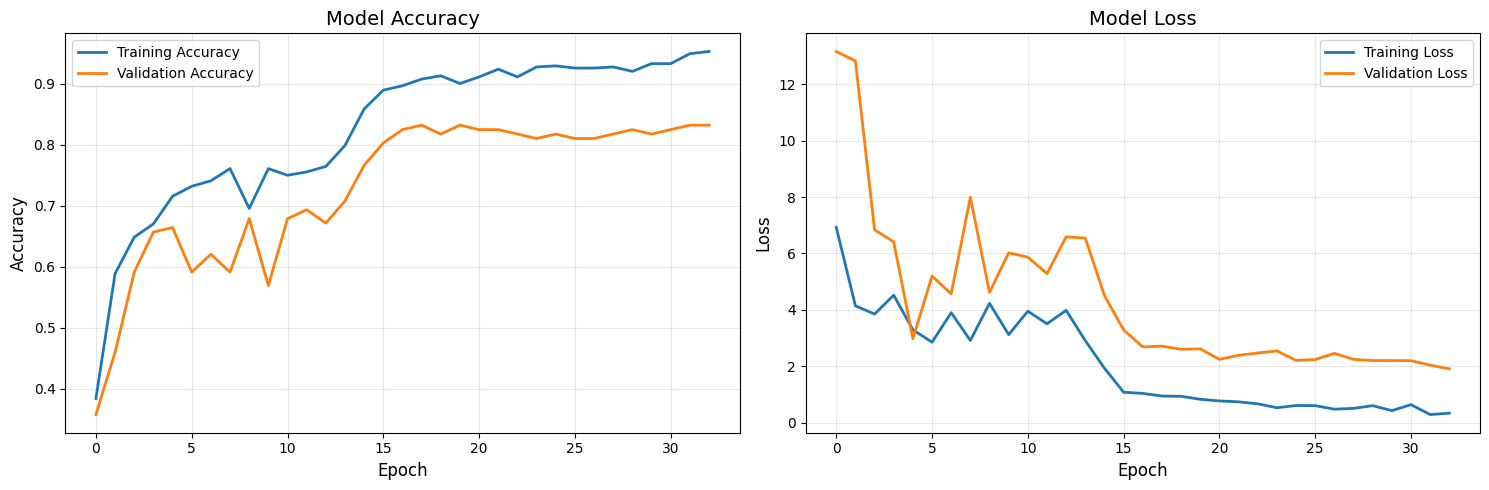

In [11]:
# MIDDLE_3

# Комбинированный Pooling + Residual connection

from tensorflow.keras.layers import GlobalAveragePooling2D, GlobalMaxPooling2D, Concatenate, Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras.regularizers import l1, l2, l1_l2

model_name = 'EfficientNetV2S' # {model_name}
alias = '_middle_3_' # {_middle_}
#val_accuracy=0



# Создание модели
import tensorflow as tf
from tensorflow.keras.applications import ResNet50, EfficientNetB0, EfficientNetV2B0, EfficientNetV2S
from tensorflow.keras import layers, Model

# Словарь моделей
MODELS = {
    'EfficientNetV2S': EfficientNetV2S,
    'EfficientNetV2B0': EfficientNetV2B0,
    'EfficientNetB0': EfficientNetB0,
    'ResNet50': ResNet50
}
'''
def dense_block(x, units, dropout_rate=0.5, l2_reg=1e-4):
    x = Dense(units, kernel_regularizer=l2(l2_reg))(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(dropout_rate)(x)
    return x
'''

# Используйте готовую функцию чтобы не думать о проекции
def residual_block(x, units, dropout_rate=0.5, l2_reg=1e-5):
    identity = x
    x = Dense(units, kernel_regularizer=l2(l2_reg))(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(dropout_rate)(x)
    
    if identity.shape[-1] != units:
        identity = Dense(units, kernel_regularizer=l2(l2_reg))(identity)
    
    return layers.Add()([identity, x])

height, width = 224, 224
#num_classes = 8  # ⬅️ ДОБАВЬТЕ ЭТУ СТРОКУ!

# 1. Сначала создаем inputs
inputs = tf.keras.Input(shape=(height, width, 3))  # ⬅️ ПЕРВЫМ ДЕЛОМ!

# 2. Базовая модель
base_model = MODELS[model_name](
    weights='imagenet',      # ✅ Предобученные веса
    include_top=False,       # ✅ Убираем старый классификатор
    input_shape=(height, width, 3)  # ⬅️ ИСПРАВЛЕНО: передаем кортеж, не переменную inputs
)
base_model.trainable = False # ✅ Замораживаем веса
x = base_model(inputs, training=False)  # ✅ BatchNorm в inference режиме

# 4. Классификатор (ваш лучший вариант)
gap = GlobalAveragePooling2D()(x)
gmp = GlobalMaxPooling2D()(x)
x = Concatenate()([gap, gmp])  # Удваиваем features
x = BatchNormalization()(x)

# Классификатор (Residual блоки вместо обычных)
x = residual_block(x, 512, dropout_rate=0.4, l2_reg=1e-5)
x = residual_block(x, 1024, dropout_rate=0.4, l2_reg=1e-5) 
x = residual_block(x, 1024, dropout_rate=0.4, l2_reg=1e-5)
#x = Dense(64, activation='relu')(x) # Финальная адаптация признаков
#x = Dropout(0.2)(x) # Минимальная регуляризация перед выходом
# 5. Выходной слой
outputs = layers.Dense(num_classes, activation='softmax')(x)

# 6. Сборка и компиляция
model = Model(inputs, outputs)
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # ✅ Для integer labels
    metrics=['accuracy']
)

print("✅ Модель создана для {} классов!".format(num_classes))
print("✅ Transfer Learning модель готова!")
print(f"🎯 {model_name} заморожена, обучаться будут только добавленные Dense слои")
model.summary()


import datetime
import os
import time
# ДОБАВЬТЕ ЭТО В САМОЕ НАЧАЛО СКРИПТА
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # 0=все, 1=INFO, 2=WARNING, 3=ERROR
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
tf.get_logger().setLevel('ERROR')
tf.autograph.set_verbosity(0)

from tensorflow.keras.callbacks import TensorBoard, EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# 2. Создаем callback
callbacks = [
    #EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True, verbose=1), # monitor='val_loss',  # ⬅️ Следим за loss (может быть стабильнее)
    ModelCheckpoint(f'./keras_lab/{model_name}/keras_{model_name}_temp.keras', monitor='val_accuracy', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', patience=9, factor=0.1, verbose=1),
    #tensorboard_callback
]

start_time = time.time()
# 4. Запускаем обучение
history = model.fit(
    train_data,
    epochs=90,
    validation_data=validation_data,
    callbacks=callbacks,
    verbose=1
)
# ВРЕМЯ
end_time = time.time()
training_time_seconds = end_time - start_time
hours = int(training_time_seconds // 3600)
minutes = int((training_time_seconds % 3600) // 60)
seconds = int(training_time_seconds % 60)
print(f"⏰ Время обучения: {hours:02d}:{minutes:02d}:{seconds:02d} (ч:м:с)")

# Оценка на валидационном датасете

best_model = tf.keras.models.load_model(f'./keras_lab/{model_name}/keras_{model_name}_temp.keras')
print(f"\n📊 ОЦЕНКА {model_name}{alias} НА ВАЛИДАЦИОННЫХ ДАННЫХ...")
val_results = best_model.evaluate(validation_data, verbose=1)
val_loss, val_accuracy = val_results

#print(f"✅ Финальная точность на валидации: {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")
#print(f"✅ Финальные потери на валидации: {val_loss:.4f}")

# Сохранение с точностью в названии
accuracy_percent = val_accuracy * 100
save_path = f'./keras_lab/{model_name}/keras_{model_name}{alias}{accuracy_percent:.2f}.keras'

best_model.save(save_path)
print(f"💾 Модель сохранена как: {save_path}")

# Визуализация результатов
import matplotlib.pyplot as plt
import numpy as np

def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # График точности
    ax1.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
    ax1.set_title('Model Accuracy', fontsize=14)
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Accuracy', fontsize=12)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # График потерь
    ax2.plot(history.history['loss'], label='Training Loss', linewidth=2)
    ax2.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    ax2.set_title('Model Loss', fontsize=14)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Loss', fontsize=12)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Построим графики
plot_training_history(history)




✅ Модель создана для 33 классов!
✅ Transfer Learning модель готова!
🎯 EfficientNetV2S заморожена, обучаться будут только добавленные Dense слои


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetv2-s    │ (None, 7, 7,      │ 20,331,360 │ input_layer_8[0]… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ efficientnetv2-s… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 1280)      │          0 │ efficientnetv2-s… │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, 2560)      │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 2560)      │     10,240 │ concatenate_4[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_26 (Dense)    │ (None, 1024)      │  2,622,464 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1024)      │      4,096 │ dense_26[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_12       │ (None, 1024)      │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_27 (Dense)    │ (None, 1024)      │  2,622,464 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_12          │ (None, 1024)      │          0 │ activation_12[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_12 (Add)        │ (None, 1024)      │          0 │ dense_27[0][0],   │
│                     │                   │            │ dropout_12[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_28 (Dense)    │ (None, 1024)      │  1,049,600 │ add_12[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1024)      │      4,096 │ dense_28[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_13       │ (None, 1024)      │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_13          │ (None, 1024)      │          0 │ activation_13[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_13 (Add)        │ (None, 1024)      │          0 │ add_12[0][0],     │
│                     │                   │            │ dropout_13[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_29 (Dense)    │ (None, 512)       │    524,800 │ add_13[0][0]    

 Total params: 27,968,129 (106.69 MB)

 Trainable params: 7,626,017 (29.09 MB)

 Non-trainable params: 20,342,112 (77.60 MB)

Epoch 1/90
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 469ms/step - accuracy: 0.2666 - loss: 13.2130
Epoch 1: val_accuracy improved from None to 0.40146, saving model to ./keras_lab/EfficientNetV2S/keras_EfficientNetV2S_temp.keras
35/35 ━━━━━━━━━━━━━━━━━━━━ 53s 818ms/step - accuracy: 0.3605 - loss: 12.0725 - val_accuracy: 0.4015 - val_loss: 19.2452 - learning_rate: 0.0010
Epoch 2/90
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.5843 - loss: 8.0061
Epoch 2: val_accuracy improved from 0.40146 to 0.56204, saving model to ./keras_lab/EfficientNetV2S/keras_EfficientNetV2S_temp.keras
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - accuracy: 0.5942 - loss: 7.9040 - val_accuracy: 0.5620 - val_loss: 11.3680 - learning_rate: 0.0010
Epoch 3/90
33/35 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.5834 - loss: 6.7882
Epoch 3: val_accuracy did not improve from 0.56204
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.6159 - loss: 5.9199 - val_accuracy: 0.5182 - val_loss: 7.3512 - learning_rate: 0.0010
Epoc

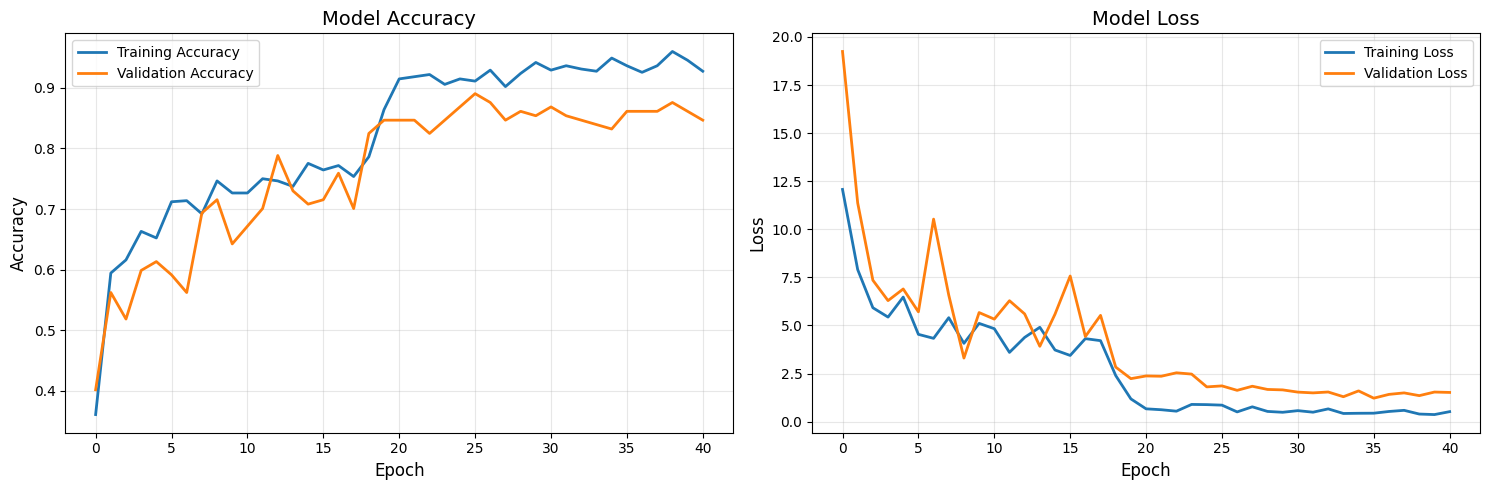

In [12]:
# MIDDLE_3

# Комбинированный Pooling + Residual connection

from tensorflow.keras.layers import GlobalAveragePooling2D, GlobalMaxPooling2D, Concatenate, Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras.regularizers import l1, l2, l1_l2

model_name = 'EfficientNetV2S' # {model_name}
alias = '_middle_4_' # {_middle_}
#val_accuracy=0



# Создание модели
import tensorflow as tf
from tensorflow.keras.applications import ResNet50, EfficientNetB0, EfficientNetV2B0, EfficientNetV2S
from tensorflow.keras import layers, Model

# Словарь моделей
MODELS = {
    'EfficientNetV2S': EfficientNetV2S,
    'EfficientNetV2B0': EfficientNetV2B0,
    'EfficientNetB0': EfficientNetB0,
    'ResNet50': ResNet50
}
'''
def dense_block(x, units, dropout_rate=0.5, l2_reg=1e-4):
    x = Dense(units, kernel_regularizer=l2(l2_reg))(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(dropout_rate)(x)
    return x
'''

# Используйте готовую функцию чтобы не думать о проекции
def residual_block(x, units, dropout_rate=0.5, l2_reg=1e-5):
    identity = x
    x = Dense(units, kernel_regularizer=l2(l2_reg))(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(dropout_rate)(x)
    
    if identity.shape[-1] != units:
        identity = Dense(units, kernel_regularizer=l2(l2_reg))(identity)
    
    return layers.Add()([identity, x])

height, width = 224, 224
#num_classes = 8  # ⬅️ ДОБАВЬТЕ ЭТУ СТРОКУ!

# 1. Сначала создаем inputs
inputs = tf.keras.Input(shape=(height, width, 3))  # ⬅️ ПЕРВЫМ ДЕЛОМ!

# 2. Базовая модель
base_model = MODELS[model_name](
    weights='imagenet',      # ✅ Предобученные веса
    include_top=False,       # ✅ Убираем старый классификатор
    input_shape=(height, width, 3)  # ⬅️ ИСПРАВЛЕНО: передаем кортеж, не переменную inputs
)
base_model.trainable = False # ✅ Замораживаем веса
x = base_model(inputs, training=False)  # ✅ BatchNorm в inference режиме

# 4. Классификатор (ваш лучший вариант)
gap = GlobalAveragePooling2D()(x)
gmp = GlobalMaxPooling2D()(x)
x = Concatenate()([gap, gmp])  # Удваиваем features
x = BatchNormalization()(x)

# Классификатор (Residual блоки вместо обычных)
x = residual_block(x, 1024, dropout_rate=0.5, l2_reg=1e-5)
x = residual_block(x, 1024, dropout_rate=0.5, l2_reg=1e-5) 
x = residual_block(x, 512, dropout_rate=0.5, l2_reg=1e-5)
x = residual_block(x, 256, dropout_rate=0.5, l2_reg=1e-5)
#x = Dense(64, activation='relu')(x) # Финальная адаптация признаков
#x = Dropout(0.2)(x) # Минимальная регуляризация перед выходом
# 5. Выходной слой
outputs = layers.Dense(num_classes, activation='softmax')(x)

# 6. Сборка и компиляция
model = Model(inputs, outputs)
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # ✅ Для integer labels
    metrics=['accuracy']
)

print("✅ Модель создана для {} классов!".format(num_classes))
print("✅ Transfer Learning модель готова!")
print(f"🎯 {model_name} заморожена, обучаться будут только добавленные Dense слои")
model.summary()


import datetime
import os
import time
# ДОБАВЬТЕ ЭТО В САМОЕ НАЧАЛО СКРИПТА
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # 0=все, 1=INFO, 2=WARNING, 3=ERROR
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
tf.get_logger().setLevel('ERROR')
tf.autograph.set_verbosity(0)

from tensorflow.keras.callbacks import TensorBoard, EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# 2. Создаем callback
callbacks = [
    #EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True, verbose=1), # monitor='val_loss',  # ⬅️ Следим за loss (может быть стабильнее)
    ModelCheckpoint(f'./keras_lab/{model_name}/keras_{model_name}_temp.keras', monitor='val_accuracy', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', patience=9, factor=0.1, verbose=1),
    #tensorboard_callback
]

start_time = time.time()
# 4. Запускаем обучение
history = model.fit(
    train_data,
    epochs=90,
    validation_data=validation_data,
    callbacks=callbacks,
    verbose=1
)
# ВРЕМЯ
end_time = time.time()
training_time_seconds = end_time - start_time
hours = int(training_time_seconds // 3600)
minutes = int((training_time_seconds % 3600) // 60)
seconds = int(training_time_seconds % 60)
print(f"⏰ Время обучения: {hours:02d}:{minutes:02d}:{seconds:02d} (ч:м:с)")

# Оценка на валидационном датасете

best_model = tf.keras.models.load_model(f'./keras_lab/{model_name}/keras_{model_name}_temp.keras')
print(f"\n📊 ОЦЕНКА {model_name}{alias} НА ВАЛИДАЦИОННЫХ ДАННЫХ...")
val_results = best_model.evaluate(validation_data, verbose=1)
val_loss, val_accuracy = val_results

#print(f"✅ Финальная точность на валидации: {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")
#print(f"✅ Финальные потери на валидации: {val_loss:.4f}")

# Сохранение с точностью в названии
accuracy_percent = val_accuracy * 100
save_path = f'./keras_lab/{model_name}/keras_{model_name}{alias}{accuracy_percent:.2f}.keras'

best_model.save(save_path)
print(f"💾 Модель сохранена как: {save_path}")

# Визуализация результатов
import matplotlib.pyplot as plt
import numpy as np

def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # График точности
    ax1.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
    ax1.set_title('Model Accuracy', fontsize=14)
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Accuracy', fontsize=12)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # График потерь
    ax2.plot(history.history['loss'], label='Training Loss', linewidth=2)
    ax2.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    ax2.set_title('Model Loss', fontsize=14)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Loss', fontsize=12)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Построим графики
plot_training_history(history)




✅ Модель создана для 33 классов!
✅ Transfer Learning модель готова!
🎯 EfficientNetV2S заморожена, обучаться будут только добавленные Dense слои


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_10      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetv2-s    │ (None, 7, 7,      │ 20,331,360 │ input_layer_10[0… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ efficientnetv2-s… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 1280)      │          0 │ efficientnetv2-s… │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_5       │ (None, 2560)      │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 2560)      │     10,240 │ concatenate_5[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_34 (Dense)    │ (None, 1024)      │  2,622,464 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1024)      │      4,096 │ dense_34[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_16       │ (None, 1024)      │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_35 (Dense)    │ (None, 1024)      │  2,622,464 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_16          │ (None, 1024)      │          0 │ activation_16[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_16 (Add)        │ (None, 1024)      │          0 │ dense_35[0][0],   │
│                     │                   │            │ dropout_16[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_36 (Dense)    │ (None, 1024)      │  1,049,600 │ add_16[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1024)      │      4,096 │ dense_36[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_17       │ (None, 1024)      │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_17          │ (None, 1024)      │          0 │ activation_17[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_17 (Add)        │ (None, 1024)      │          0 │ add_16[0][0],     │
│                     │                   │            │ dropout_17[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_37 (Dense)    │ (None, 1024)      │  1,049,600 │ add_17[0][0]    

 Total params: 29,838,209 (113.82 MB)

 Trainable params: 9,492,513 (36.21 MB)

 Non-trainable params: 20,345,696 (77.61 MB)

Epoch 1/90
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 480ms/step - accuracy: 0.2448 - loss: 13.7663
Epoch 1: val_accuracy improved from None to 0.24088, saving model to ./keras_lab/EfficientNetV2S/keras_EfficientNetV2S_temp.keras
35/35 ━━━━━━━━━━━━━━━━━━━━ 53s 828ms/step - accuracy: 0.3333 - loss: 13.1407 - val_accuracy: 0.2409 - val_loss: 27.2365 - learning_rate: 0.0010
Epoch 2/90
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.5142 - loss: 12.0394
Epoch 2: val_accuracy improved from 0.24088 to 0.38686, saving model to ./keras_lab/EfficientNetV2S/keras_EfficientNetV2S_temp.keras
35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 122ms/step - accuracy: 0.5236 - loss: 12.2277 - val_accuracy: 0.3869 - val_loss: 11.3285 - learning_rate: 0.0010
Epoch 3/90
34/35 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.4783 - loss: 11.5875
Epoch 3: val_accuracy improved from 0.38686 to 0.54745, saving model to ./keras_lab/EfficientNetV2S/keras_EfficientNetV2S_temp.keras
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - accuracy: 0.5417

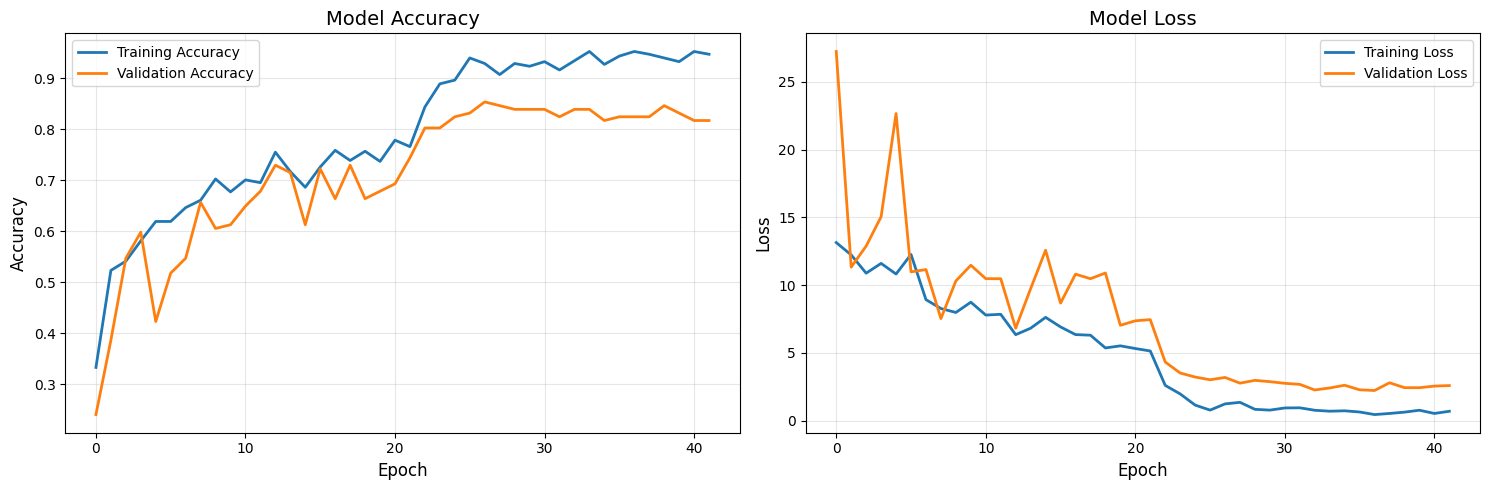

In [13]:
# MIDDLE_5

# Комбинированный Pooling + Residual connection

from tensorflow.keras.layers import GlobalAveragePooling2D, GlobalMaxPooling2D, Concatenate, Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras.regularizers import l1, l2, l1_l2

model_name = 'EfficientNetV2S' # {model_name}
alias = '_middle_5_' # {_middle_}
#val_accuracy=0



# Создание модели
import tensorflow as tf
from tensorflow.keras.applications import ResNet50, EfficientNetB0, EfficientNetV2B0, EfficientNetV2S
from tensorflow.keras import layers, Model

# Словарь моделей
MODELS = {
    'EfficientNetV2S': EfficientNetV2S,
    'EfficientNetV2B0': EfficientNetV2B0,
    'EfficientNetB0': EfficientNetB0,
    'ResNet50': ResNet50
}
'''
def dense_block(x, units, dropout_rate=0.5, l2_reg=1e-4):
    x = Dense(units, kernel_regularizer=l2(l2_reg))(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(dropout_rate)(x)
    return x
'''

# Используйте готовую функцию чтобы не думать о проекции
def residual_block(x, units, dropout_rate=0.5, l2_reg=1e-5):
    identity = x
    x = Dense(units, kernel_regularizer=l2(l2_reg))(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(dropout_rate)(x)
    
    if identity.shape[-1] != units:
        identity = Dense(units, kernel_regularizer=l2(l2_reg))(identity)
    
    return layers.Add()([identity, x])

height, width = 224, 224
#num_classes = 8  # ⬅️ ДОБАВЬТЕ ЭТУ СТРОКУ!

# 1. Сначала создаем inputs
inputs = tf.keras.Input(shape=(height, width, 3))  # ⬅️ ПЕРВЫМ ДЕЛОМ!

# 2. Базовая модель
base_model = MODELS[model_name](
    weights='imagenet',      # ✅ Предобученные веса
    include_top=False,       # ✅ Убираем старый классификатор
    input_shape=(height, width, 3)  # ⬅️ ИСПРАВЛЕНО: передаем кортеж, не переменную inputs
)
base_model.trainable = False # ✅ Замораживаем веса
x = base_model(inputs, training=False)  # ✅ BatchNorm в inference режиме

# 4. Классификатор (ваш лучший вариант)
gap = GlobalAveragePooling2D()(x)
gmp = GlobalMaxPooling2D()(x)
x = Concatenate()([gap, gmp])  # Удваиваем features
x = BatchNormalization()(x)

# Классификатор (Residual блоки вместо обычных)
x = residual_block(x, 1024, dropout_rate=0.5, l2_reg=1e-5)
x = residual_block(x, 1024, dropout_rate=0.5, l2_reg=1e-5) 
x = residual_block(x, 1024, dropout_rate=0.5, l2_reg=1e-5)
x = residual_block(x, 512, dropout_rate=0.5, l2_reg=1e-5)
x = residual_block(x, 1024, dropout_rate=0.5, l2_reg=1e-5)
#x = Dense(64, activation='relu')(x) # Финальная адаптация признаков
#x = Dropout(0.2)(x) # Минимальная регуляризация перед выходом
# 5. Выходной слой
outputs = layers.Dense(num_classes, activation='softmax')(x)

# 6. Сборка и компиляция
model = Model(inputs, outputs)
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # ✅ Для integer labels
    metrics=['accuracy']
)

print("✅ Модель создана для {} классов!".format(num_classes))
print("✅ Transfer Learning модель готова!")
print(f"🎯 {model_name} заморожена, обучаться будут только добавленные Dense слои")
model.summary()


import datetime
import os
import time
# ДОБАВЬТЕ ЭТО В САМОЕ НАЧАЛО СКРИПТА
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # 0=все, 1=INFO, 2=WARNING, 3=ERROR
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
tf.get_logger().setLevel('ERROR')
tf.autograph.set_verbosity(0)

from tensorflow.keras.callbacks import TensorBoard, EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# 2. Создаем callback
callbacks = [
    #EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True, verbose=1), # monitor='val_loss',  # ⬅️ Следим за loss (может быть стабильнее)
    ModelCheckpoint(f'./keras_lab/{model_name}/keras_{model_name}_temp.keras', monitor='val_accuracy', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', patience=9, factor=0.1, verbose=1),
    #tensorboard_callback
]

start_time = time.time()
# 4. Запускаем обучение
history = model.fit(
    train_data,
    epochs=90,
    validation_data=validation_data,
    callbacks=callbacks,
    verbose=1
)
# ВРЕМЯ
end_time = time.time()
training_time_seconds = end_time - start_time
hours = int(training_time_seconds // 3600)
minutes = int((training_time_seconds % 3600) // 60)
seconds = int(training_time_seconds % 60)
print(f"⏰ Время обучения: {hours:02d}:{minutes:02d}:{seconds:02d} (ч:м:с)")

# Оценка на валидационном датасете

best_model = tf.keras.models.load_model(f'./keras_lab/{model_name}/keras_{model_name}_temp.keras')
print(f"\n📊 ОЦЕНКА {model_name}{alias} НА ВАЛИДАЦИОННЫХ ДАННЫХ...")
val_results = best_model.evaluate(validation_data, verbose=1)
val_loss, val_accuracy = val_results

#print(f"✅ Финальная точность на валидации: {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")
#print(f"✅ Финальные потери на валидации: {val_loss:.4f}")

# Сохранение с точностью в названии
accuracy_percent = val_accuracy * 100
save_path = f'./keras_lab/{model_name}/keras_{model_name}{alias}{accuracy_percent:.2f}.keras'

best_model.save(save_path)
print(f"💾 Модель сохранена как: {save_path}")

# Визуализация результатов
import matplotlib.pyplot as plt
import numpy as np

def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # График точности
    ax1.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
    ax1.set_title('Model Accuracy', fontsize=14)
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Accuracy', fontsize=12)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # График потерь
    ax2.plot(history.history['loss'], label='Training Loss', linewidth=2)
    ax2.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    ax2.set_title('Model Loss', fontsize=14)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Loss', fontsize=12)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Построим графики
plot_training_history(history)




✅ Модель создана для 33 классов!
✅ Transfer Learning модель готова!
🎯 EfficientNetV2S заморожена, обучаться будут только добавленные Dense слои


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_12      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetv2-s    │ (None, 7, 7,      │ 20,331,360 │ input_layer_12[0… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ efficientnetv2-s… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 1280)      │          0 │ efficientnetv2-s… │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_6       │ (None, 2560)      │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 2560)      │     10,240 │ concatenate_6[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_43 (Dense)    │ (None, 1024)      │  2,622,464 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1024)      │      4,096 │ dense_43[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_21       │ (None, 1024)      │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_44 (Dense)    │ (None, 1024)      │  2,622,464 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_21          │ (None, 1024)      │          0 │ activation_21[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_21 (Add)        │ (None, 1024)      │          0 │ dense_44[0][0],   │
│                     │                   │            │ dropout_21[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_45 (Dense)    │ (None, 512)       │    524,800 │ add_21[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ dense_45[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_22       │ (None, 512)       │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_46 (Dense)    │ (None, 512)       │    524,800 │ add_21[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_22          │ (None, 512)       │          0 │ activation_22[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_22 (Add)        │ (None, 512)       │          0 │ dense_46[0][0],   │
│                     │                   │            │ dropout_22[0][0]

 Total params: 26,914,433 (102.67 MB)

 Trainable params: 6,574,369 (25.08 MB)

 Non-trainable params: 20,340,064 (77.59 MB)

Epoch 1/90
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 437ms/step - accuracy: 0.2520 - loss: 12.1868
Epoch 1: val_accuracy improved from None to 0.35036, saving model to ./keras_lab/EfficientNetV2S/keras_EfficientNetV2S_temp.keras
35/35 ━━━━━━━━━━━━━━━━━━━━ 51s 774ms/step - accuracy: 0.3551 - loss: 11.1207 - val_accuracy: 0.3504 - val_loss: 19.4368 - learning_rate: 0.0010
Epoch 2/90
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.6084 - loss: 5.6102
Epoch 2: val_accuracy improved from 0.35036 to 0.53285, saving model to ./keras_lab/EfficientNetV2S/keras_EfficientNetV2S_temp.keras
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - accuracy: 0.6214 - loss: 5.4904 - val_accuracy: 0.5328 - val_loss: 12.8262 - learning_rate: 0.0010
Epoch 3/90
33/35 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.6280 - loss: 6.7047
Epoch 3: val_accuracy did not improve from 0.53285
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.6141 - loss: 6.9894 - val_accuracy: 0.4526 - val_loss: 18.8854 - learning_rate: 0.0010
Epo

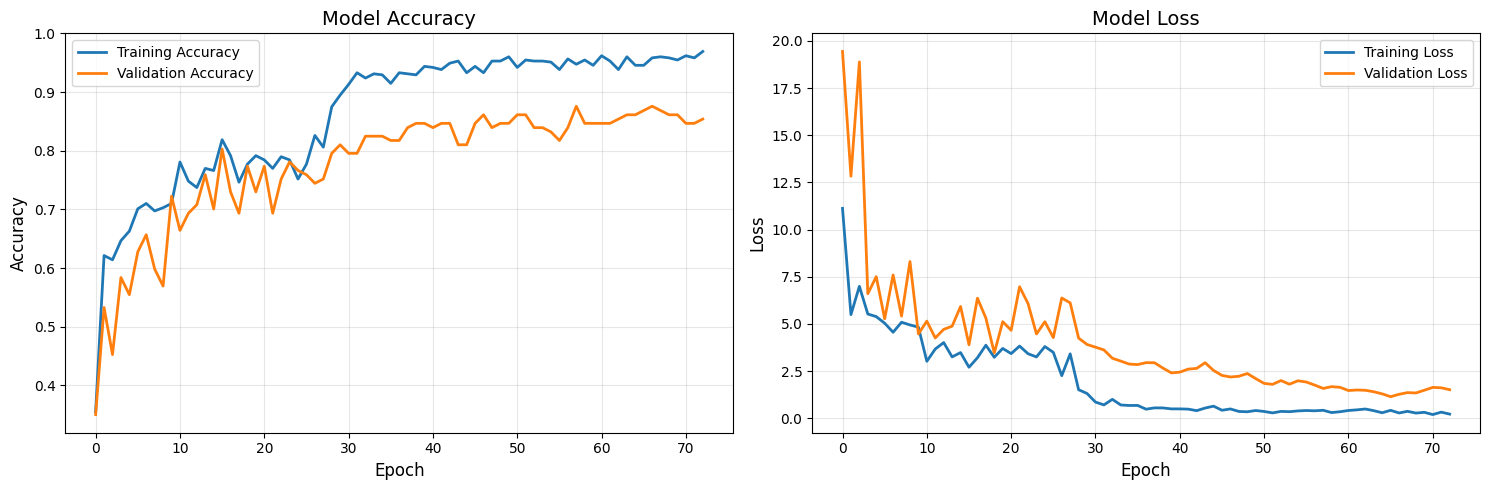

In [14]:
# MIDDLE_6

# Комбинированный Pooling + Residual connection

from tensorflow.keras.layers import GlobalAveragePooling2D, GlobalMaxPooling2D, Concatenate, Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras.regularizers import l1, l2, l1_l2

model_name = 'EfficientNetV2S' # {model_name}
alias = '_middle_6_' # {_middle_}
#val_accuracy=0



# Создание модели
import tensorflow as tf
from tensorflow.keras.applications import ResNet50, EfficientNetB0, EfficientNetV2B0, EfficientNetV2S
from tensorflow.keras import layers, Model

# Словарь моделей
MODELS = {
    'EfficientNetV2S': EfficientNetV2S,
    'EfficientNetV2B0': EfficientNetV2B0,
    'EfficientNetB0': EfficientNetB0,
    'ResNet50': ResNet50
}
'''
def dense_block(x, units, dropout_rate=0.5, l2_reg=1e-4):
    x = Dense(units, kernel_regularizer=l2(l2_reg))(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(dropout_rate)(x)
    return x
'''

# Используйте готовую функцию чтобы не думать о проекции
def residual_block(x, units, dropout_rate=0.5, l2_reg=1e-5):
    identity = x
    x = Dense(units, kernel_regularizer=l2(l2_reg))(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(dropout_rate)(x)
    
    if identity.shape[-1] != units:
        identity = Dense(units, kernel_regularizer=l2(l2_reg))(identity)
    
    return layers.Add()([identity, x])

height, width = 224, 224
#num_classes = 8  # ⬅️ ДОБАВЬТЕ ЭТУ СТРОКУ!

# 1. Сначала создаем inputs
inputs = tf.keras.Input(shape=(height, width, 3))  # ⬅️ ПЕРВЫМ ДЕЛОМ!

# 2. Базовая модель
base_model = MODELS[model_name](
    weights='imagenet',      # ✅ Предобученные веса
    include_top=False,       # ✅ Убираем старый классификатор
    input_shape=(height, width, 3)  # ⬅️ ИСПРАВЛЕНО: передаем кортеж, не переменную inputs
)
base_model.trainable = False # ✅ Замораживаем веса
x = base_model(inputs, training=False)  # ✅ BatchNorm в inference режиме

# 4. Классификатор (ваш лучший вариант)
gap = GlobalAveragePooling2D()(x)
gmp = GlobalMaxPooling2D()(x)
x = Concatenate()([gap, gmp])  # Удваиваем features
x = BatchNormalization()(x)

# Классификатор (Residual блоки вместо обычных)
x = residual_block(x, 1024, dropout_rate=0.4, l2_reg=1e-5)
x = residual_block(x, 512, dropout_rate=0.4, l2_reg=1e-5) 
x = residual_block(x, 256, dropout_rate=0.4, l2_reg=1e-5)
#x = Dense(64, activation='relu')(x) # Финальная адаптация признаков
#x = Dropout(0.2)(x) # Минимальная регуляризация перед выходом
# 5. Выходной слой
outputs = layers.Dense(num_classes, activation='softmax')(x)

# 6. Сборка и компиляция
model = Model(inputs, outputs)
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # ✅ Для integer labels
    metrics=['accuracy']
)

print("✅ Модель создана для {} классов!".format(num_classes))
print("✅ Transfer Learning модель готова!")
print(f"🎯 {model_name} заморожена, обучаться будут только добавленные Dense слои")
model.summary()


import datetime
import os
import time
# ДОБАВЬТЕ ЭТО В САМОЕ НАЧАЛО СКРИПТА
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # 0=все, 1=INFO, 2=WARNING, 3=ERROR
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
tf.get_logger().setLevel('ERROR')
tf.autograph.set_verbosity(0)

from tensorflow.keras.callbacks import TensorBoard, EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# 2. Создаем callback
callbacks = [
    #EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True, verbose=1), # monitor='val_loss',  # ⬅️ Следим за loss (может быть стабильнее)
    ModelCheckpoint(f'./keras_lab/{model_name}/keras_{model_name}_temp.keras', monitor='val_accuracy', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', patience=9, factor=0.1, verbose=1),
    #tensorboard_callback
]

start_time = time.time()
# 4. Запускаем обучение
history = model.fit(
    train_data,
    epochs=90,
    validation_data=validation_data,
    callbacks=callbacks,
    verbose=1
)
# ВРЕМЯ
end_time = time.time()
training_time_seconds = end_time - start_time
hours = int(training_time_seconds // 3600)
minutes = int((training_time_seconds % 3600) // 60)
seconds = int(training_time_seconds % 60)
print(f"⏰ Время обучения: {hours:02d}:{minutes:02d}:{seconds:02d} (ч:м:с)")

# Оценка на валидационном датасете

best_model = tf.keras.models.load_model(f'./keras_lab/{model_name}/keras_{model_name}_temp.keras')
print(f"\n📊 ОЦЕНКА {model_name}{alias} НА ВАЛИДАЦИОННЫХ ДАННЫХ...")
val_results = best_model.evaluate(validation_data, verbose=1)
val_loss, val_accuracy = val_results

#print(f"✅ Финальная точность на валидации: {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")
#print(f"✅ Финальные потери на валидации: {val_loss:.4f}")

# Сохранение с точностью в названии
accuracy_percent = val_accuracy * 100
save_path = f'./keras_lab/{model_name}/keras_{model_name}{alias}{accuracy_percent:.2f}.keras'

best_model.save(save_path)
print(f"💾 Модель сохранена как: {save_path}")

# Визуализация результатов
import matplotlib.pyplot as plt
import numpy as np

def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # График точности
    ax1.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
    ax1.set_title('Model Accuracy', fontsize=14)
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Accuracy', fontsize=12)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # График потерь
    ax2.plot(history.history['loss'], label='Training Loss', linewidth=2)
    ax2.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    ax2.set_title('Model Loss', fontsize=14)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Loss', fontsize=12)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Построим графики
plot_training_history(history)




✅ Модель создана для 33 классов!
✅ Transfer Learning модель готова!
🎯 EfficientNetV2S заморожена, обучаться будут только добавленные Dense слои


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_14      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetv2-s    │ (None, 7, 7,      │ 20,331,360 │ input_layer_14[0… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ efficientnetv2-s… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 1280)      │          0 │ efficientnetv2-s… │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_7       │ (None, 2560)      │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 2560)      │     10,240 │ concatenate_7[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_50 (Dense)    │ (None, 1024)      │  2,622,464 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1024)      │      4,096 │ dense_50[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_24       │ (None, 1024)      │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_51 (Dense)    │ (None, 1024)      │  2,622,464 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_24          │ (None, 1024)      │          0 │ activation_24[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_24 (Add)        │ (None, 1024)      │          0 │ dense_51[0][0],   │
│                     │                   │            │ dropout_24[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_52 (Dense)    │ (None, 512)       │    524,800 │ add_24[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ dense_52[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_25       │ (None, 512)       │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_53 (Dense)    │ (None, 512)       │    524,800 │ add_24[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_25          │ (None, 512)       │          0 │ activation_25[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_25 (Add)        │ (None, 512)       │          0 │ dense_53[0][0],   │
│                     │                   │            │ dropout_25[0][0]

 Total params: 26,914,433 (102.67 MB)

 Trainable params: 6,574,369 (25.08 MB)

 Non-trainable params: 20,340,064 (77.59 MB)

Epoch 1/90
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 486ms/step - accuracy: 0.2706 - loss: 13.2815
Epoch 1: val_accuracy improved from None to 0.39416, saving model to ./keras_lab/EfficientNetV2S/keras_EfficientNetV2S_temp.keras
35/35 ━━━━━━━━━━━━━━━━━━━━ 52s 856ms/step - accuracy: 0.3750 - loss: 11.5683 - val_accuracy: 0.3942 - val_loss: 20.0512 - learning_rate: 0.0010
Epoch 2/90
34/35 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.6038 - loss: 5.8602
Epoch 2: val_accuracy improved from 0.39416 to 0.49635, saving model to ./keras_lab/EfficientNetV2S/keras_EfficientNetV2S_temp.keras
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - accuracy: 0.6214 - loss: 5.5821 - val_accuracy: 0.4964 - val_loss: 9.2376 - learning_rate: 0.0010
Epoch 3/90
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.6389 - loss: 5.3204
Epoch 3: val_accuracy did not improve from 0.49635
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.6594 - loss: 4.8856 - val_accuracy: 0.4891 - val_loss: 10.9834 - learning_rate: 0.0010
Epoc

2025-11-06 16:04:24.211415: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 9634048 bytes after encountering the first element of size 9634048 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


34/35 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.7540 - loss: 2.9439
Epoch 20: val_accuracy did not improve from 0.76642
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - accuracy: 0.7645 - loss: 3.0384 - val_accuracy: 0.7445 - val_loss: 6.0479 - learning_rate: 0.0010
Epoch 21/90
34/35 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.7613 - loss: 3.5676
Epoch 21: val_accuracy did not improve from 0.76642
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.7609 - loss: 3.2796 - val_accuracy: 0.7153 - val_loss: 6.4540 - learning_rate: 0.0010
Epoch 22/90
33/35 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.7658 - loss: 2.9820
Epoch 22: val_accuracy did not improve from 0.76642
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.7663 - loss: 3.3158 - val_accuracy: 0.7664 - val_loss: 6.2998 - learning_rate: 0.0010
Epoch 23/90
34/35 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.7374 - loss: 3.7149
Epoch 23: val_accuracy did not improve from 0.76642
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step 

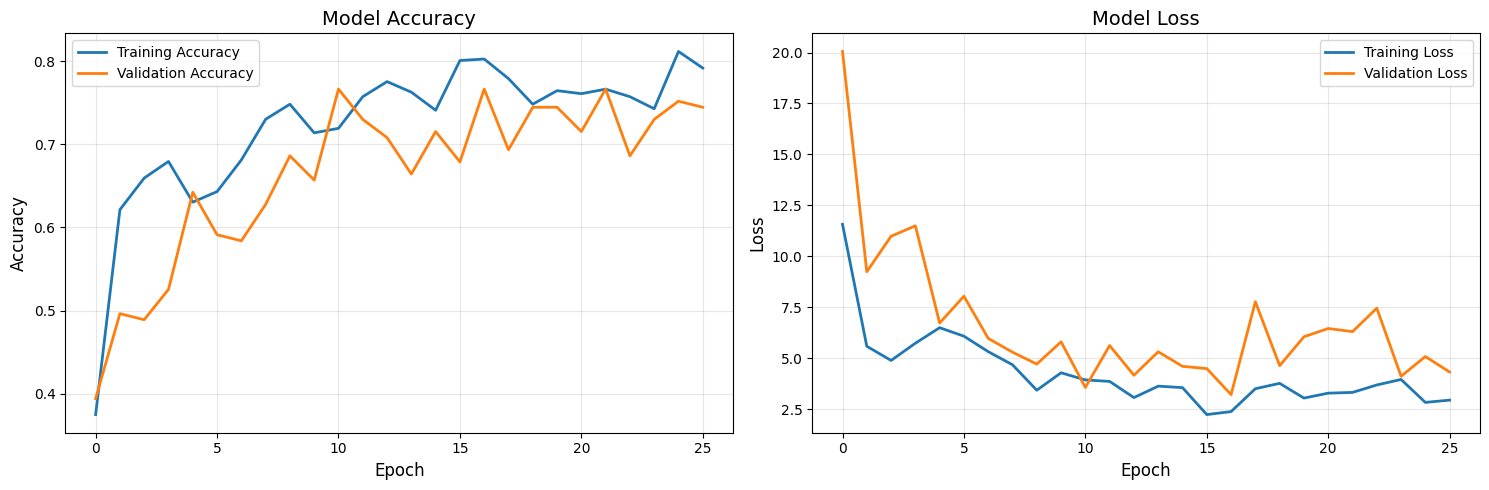

In [15]:
# MIDDLE_7

# Комбинированный Pooling + Residual connection

from tensorflow.keras.layers import GlobalAveragePooling2D, GlobalMaxPooling2D, Concatenate, Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras.regularizers import l1, l2, l1_l2

model_name = 'EfficientNetV2S' # {model_name}
alias = '_middle_7_' # {_middle_}
#val_accuracy=0



# Создание модели
import tensorflow as tf
from tensorflow.keras.applications import ResNet50, EfficientNetB0, EfficientNetV2B0, EfficientNetV2S
from tensorflow.keras import layers, Model

# Словарь моделей
MODELS = {
    'EfficientNetV2S': EfficientNetV2S,
    'EfficientNetV2B0': EfficientNetV2B0,
    'EfficientNetB0': EfficientNetB0,
    'ResNet50': ResNet50
}
'''
def dense_block(x, units, dropout_rate=0.5, l2_reg=1e-4):
    x = Dense(units, kernel_regularizer=l2(l2_reg))(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(dropout_rate)(x)
    return x
'''

# Используйте готовую функцию чтобы не думать о проекции
def residual_block(x, units, dropout_rate=0.5, l2_reg=1e-5):
    identity = x
    x = Dense(units, kernel_regularizer=l2(l2_reg))(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(dropout_rate)(x)
    
    if identity.shape[-1] != units:
        identity = Dense(units, kernel_regularizer=l2(l2_reg))(identity)
    
    return layers.Add()([identity, x])

height, width = 224, 224
#num_classes = 8  # ⬅️ ДОБАВЬТЕ ЭТУ СТРОКУ!

# 1. Сначала создаем inputs
inputs = tf.keras.Input(shape=(height, width, 3))  # ⬅️ ПЕРВЫМ ДЕЛОМ!

# 2. Базовая модель
base_model = MODELS[model_name](
    weights='imagenet',      # ✅ Предобученные веса
    include_top=False,       # ✅ Убираем старый классификатор
    input_shape=(height, width, 3)  # ⬅️ ИСПРАВЛЕНО: передаем кортеж, не переменную inputs
)
base_model.trainable = False # ✅ Замораживаем веса
x = base_model(inputs, training=False)  # ✅ BatchNorm в inference режиме

# 4. Классификатор (ваш лучший вариант)
gap = GlobalAveragePooling2D()(x)
gmp = GlobalMaxPooling2D()(x)
x = Concatenate()([gap, gmp])  # Удваиваем features
x = BatchNormalization()(x)

# Классификатор (Residual блоки вместо обычных)
x = residual_block(x, 1024, dropout_rate=0.4, l2_reg=1e-5)
x = residual_block(x, 512, dropout_rate=0.3, l2_reg=1e-5) 
x = residual_block(x, 256, dropout_rate=0.3, l2_reg=1e-5)
#x = Dense(64, activation='relu')(x) # Финальная адаптация признаков
#x = Dropout(0.2)(x) # Минимальная регуляризация перед выходом
# 5. Выходной слой
outputs = layers.Dense(num_classes, activation='softmax')(x)

# 6. Сборка и компиляция
model = Model(inputs, outputs)
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # ✅ Для integer labels
    metrics=['accuracy']
)

print("✅ Модель создана для {} классов!".format(num_classes))
print("✅ Transfer Learning модель готова!")
print(f"🎯 {model_name} заморожена, обучаться будут только добавленные Dense слои")
model.summary()


import datetime
import os
import time
# ДОБАВЬТЕ ЭТО В САМОЕ НАЧАЛО СКРИПТА
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # 0=все, 1=INFO, 2=WARNING, 3=ERROR
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
tf.get_logger().setLevel('ERROR')
tf.autograph.set_verbosity(0)

from tensorflow.keras.callbacks import TensorBoard, EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# 2. Создаем callback
callbacks = [
    #EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True, verbose=1), # monitor='val_loss',  # ⬅️ Следим за loss (может быть стабильнее)
    ModelCheckpoint(f'./keras_lab/{model_name}/keras_{model_name}_temp.keras', monitor='val_accuracy', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', patience=9, factor=0.1, verbose=1),
    #tensorboard_callback
]

start_time = time.time()
# 4. Запускаем обучение
history = model.fit(
    train_data,
    epochs=90,
    validation_data=validation_data,
    callbacks=callbacks,
    verbose=1
)
# ВРЕМЯ
end_time = time.time()
training_time_seconds = end_time - start_time
hours = int(training_time_seconds // 3600)
minutes = int((training_time_seconds % 3600) // 60)
seconds = int(training_time_seconds % 60)
print(f"⏰ Время обучения: {hours:02d}:{minutes:02d}:{seconds:02d} (ч:м:с)")

# Оценка на валидационном датасете

best_model = tf.keras.models.load_model(f'./keras_lab/{model_name}/keras_{model_name}_temp.keras')
print(f"\n📊 ОЦЕНКА {model_name}{alias} НА ВАЛИДАЦИОННЫХ ДАННЫХ...")
val_results = best_model.evaluate(validation_data, verbose=1)
val_loss, val_accuracy = val_results

#print(f"✅ Финальная точность на валидации: {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")
#print(f"✅ Финальные потери на валидации: {val_loss:.4f}")

# Сохранение с точностью в названии
accuracy_percent = val_accuracy * 100
save_path = f'./keras_lab/{model_name}/keras_{model_name}{alias}{accuracy_percent:.2f}.keras'

best_model.save(save_path)
print(f"💾 Модель сохранена как: {save_path}")

# Визуализация результатов
import matplotlib.pyplot as plt
import numpy as np

def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # График точности
    ax1.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
    ax1.set_title('Model Accuracy', fontsize=14)
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Accuracy', fontsize=12)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # График потерь
    ax2.plot(history.history['loss'], label='Training Loss', linewidth=2)
    ax2.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    ax2.set_title('Model Loss', fontsize=14)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Loss', fontsize=12)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Построим графики
plot_training_history(history)




✅ Модель создана для 33 классов!
✅ Transfer Learning модель готова!
🎯 EfficientNetV2S заморожена, обучаться будут только добавленные Dense слои


Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_18      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetv2-s    │ (None, 7, 7,      │ 20,331,360 │ input_layer_18[0… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ efficientnetv2-s… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 1280)      │          0 │ efficientnetv2-s… │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_9       │ (None, 2560)      │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 2560)      │     10,240 │ concatenate_9[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_64 (Dense)    │ (None, 1024)      │  2,622,464 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1024)      │      4,096 │ dense_64[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_30       │ (None, 1024)      │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_65 (Dense)    │ (None, 1024)      │  2,622,464 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_30          │ (None, 1024)      │          0 │ activation_30[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_30 (Add)        │ (None, 1024)      │          0 │ dense_65[0][0],   │
│                     │                   │            │ dropout_30[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_66 (Dense)    │ (None, 512)       │    524,800 │ add_30[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ dense_66[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_31       │ (None, 512)       │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_67 (Dense)    │ (None, 512)       │    524,800 │ add_30[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_31          │ (None, 512)       │          0 │ activation_31[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_31 (Add)        │ (None, 512)       │          0 │ dense_67[0][0],   │
│                     │                   │            │ dropout_31[0][0]

 Total params: 26,914,433 (102.67 MB)

 Trainable params: 6,574,369 (25.08 MB)

...

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.7625 - loss: 3.5132
Epoch 19: val_accuracy did not improve from 0.77372
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.7717 - loss: 3.6850 - val_accuracy: 0.7591 - val_loss: 4.6570 - learning_rate: 0.0010
Epoch 20/90
33/35 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.7943 - loss: 3.0298
Epoch 20: val_accuracy did not improve from 0.77372
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - accuracy: 0.7645 - loss: 3.1526 - val_accuracy: 0.7226 - val_loss: 5.7857 - learning_rate: 0.0010
Epoch 21/90
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.7678 - loss: 3.2380
Epoch 21: val_accuracy did not improve from 0.77372
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.7772 - loss: 3.2939 - val_accuracy: 0.7153 - val_loss: 6.0432 - learning_rate: 0.0010
Epoch 22/90
34/35 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.8217 - loss: 2.0887
Epoch 22: val_accuracy did not improve from 0.77372
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step 

2025-11-06 16:13:31.359287: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 9634048 bytes after encountering the first element of size 9634048 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


34/35 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.9125 - loss: 0.7578
Epoch 34: val_accuracy did not improve from 0.82482
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.9221 - loss: 0.5922 - val_accuracy: 0.8102 - val_loss: 2.3144 - learning_rate: 1.0000e-04
Epoch 35/90
33/35 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9289 - loss: 0.5971
Epoch 35: val_accuracy improved from 0.82482 to 0.83212, saving model to ./keras_lab/EfficientNetV2S/keras_EfficientNetV2S_temp.keras
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - accuracy: 0.9275 - loss: 0.6785 - val_accuracy: 0.8321 - val_loss: 1.9318 - learning_rate: 1.0000e-04
Epoch 36/90
34/35 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.9274 - loss: 0.6132
Epoch 36: val_accuracy did not improve from 0.83212
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.9348 - loss: 0.4626 - val_accuracy: 0.8248 - val_loss: 1.7435 - learning_rate: 1.0000e-04
Epoch 37/90
34/35 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.9480 - loss: 0.467

2025-11-06 16:14:08.343288: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 9634048 bytes after encountering the first element of size 9634048 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


34/35 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.9353 - loss: 0.3133
Epoch 50: val_accuracy did not improve from 0.84672
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.9330 - loss: 0.4165 - val_accuracy: 0.8321 - val_loss: 1.6781 - learning_rate: 1.0000e-04
Epoch 51/90
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9128 - loss: 0.7504
Epoch 51: val_accuracy did not improve from 0.84672
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.9312 - loss: 0.6049 - val_accuracy: 0.8321 - val_loss: 1.7632 - learning_rate: 1.0000e-04
Epoch 52/90
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9440 - loss: 0.4742
Epoch 52: val_accuracy did not improve from 0.84672

Epoch 52: ReduceLROnPlateau reducing learning rate to 1.0000000474974514e-05.
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.9547 - loss: 0.3485 - val_accuracy: 0.8248 - val_loss: 1.7978 - learning_rate: 1.0000e-04
Epoch 53/90
34/35 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9577 - loss: 0.3308
E

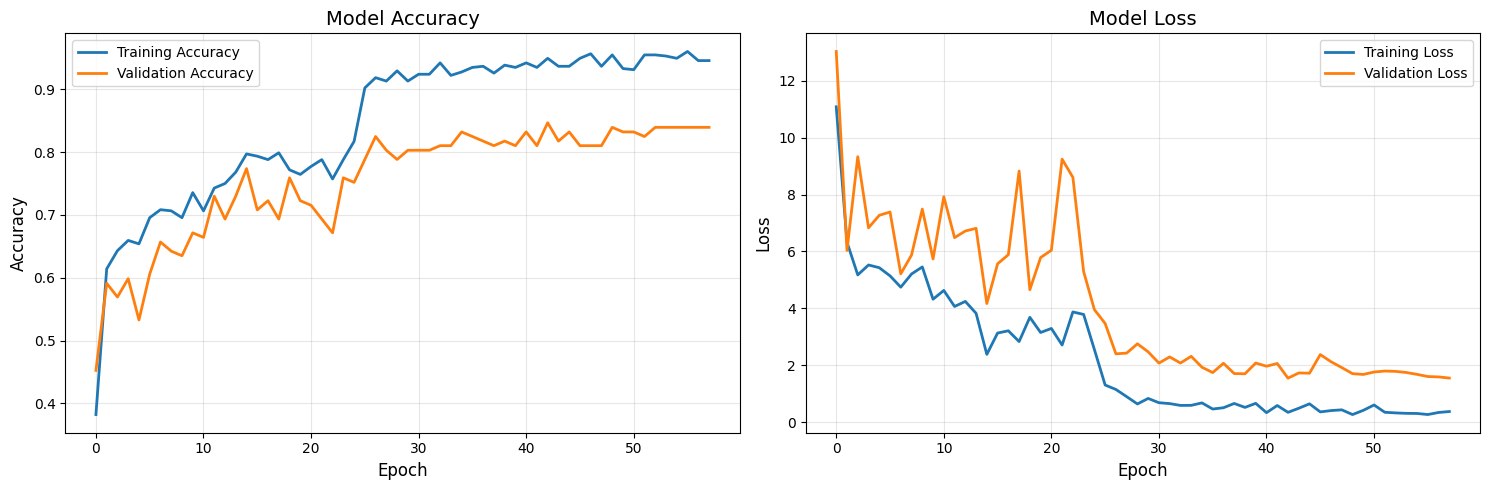

In [17]:
# MIDDLE_8

# Комбинированный Pooling + Residual connection

from tensorflow.keras.layers import GlobalAveragePooling2D, GlobalMaxPooling2D, Concatenate, Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras.regularizers import l1, l2, l1_l2

model_name = 'EfficientNetV2S' # {model_name}
alias = '_middle_8_' # {_middle_}
#val_accuracy=0



# Создание модели
import tensorflow as tf
from tensorflow.keras.applications import ResNet50, EfficientNetB0, EfficientNetV2B0, EfficientNetV2S
from tensorflow.keras import layers, Model

# Словарь моделей
MODELS = {
    'EfficientNetV2S': EfficientNetV2S,
    'EfficientNetV2B0': EfficientNetV2B0,
    'EfficientNetB0': EfficientNetB0,
    'ResNet50': ResNet50
}
'''
def dense_block(x, units, dropout_rate=0.5, l2_reg=1e-4):
    x = Dense(units, kernel_regularizer=l2(l2_reg))(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(dropout_rate)(x)
    return x
'''

# Используйте готовую функцию чтобы не думать о проекции
def residual_block(x, units, dropout_rate=0.5, l2_reg=1e-5):
    identity = x
    x = Dense(units, kernel_regularizer=l2(l2_reg))(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(dropout_rate)(x)
    
    if identity.shape[-1] != units:
        identity = Dense(units, kernel_regularizer=l2(l2_reg))(identity)
    
    return layers.Add()([identity, x])

height, width = 224, 224
#num_classes = 8  # ⬅️ ДОБАВЬТЕ ЭТУ СТРОКУ!

# 1. Сначала создаем inputs
inputs = tf.keras.Input(shape=(height, width, 3))  # ⬅️ ПЕРВЫМ ДЕЛОМ!

# 2. Базовая модель
base_model = MODELS[model_name](
    weights='imagenet',      # ✅ Предобученные веса
    include_top=False,       # ✅ Убираем старый классификатор
    input_shape=(height, width, 3)  # ⬅️ ИСПРАВЛЕНО: передаем кортеж, не переменную inputs
)
base_model.trainable = False # ✅ Замораживаем веса
x = base_model(inputs, training=False)  # ✅ BatchNorm в inference режиме

# 4. Классификатор (ваш лучший вариант)
gap = GlobalAveragePooling2D()(x)
gmp = GlobalMaxPooling2D()(x)
x = Concatenate()([gap, gmp])  # Удваиваем features
x = BatchNormalization()(x)

# Классификатор (Residual блоки вместо обычных)
x = residual_block(x, 1024, dropout_rate=0.3, l2_reg=1e-5)
x = residual_block(x, 512, dropout_rate=0.4, l2_reg=1e-5) 
x = residual_block(x, 256, dropout_rate=0.5, l2_reg=1e-5)
#x = Dense(64, activation='relu')(x) # Финальная адаптация признаков
#x = Dropout(0.2)(x) # Минимальная регуляризация перед выходом
# 5. Выходной слой
outputs = layers.Dense(num_classes, activation='softmax')(x)

# 6. Сборка и компиляция
model = Model(inputs, outputs)
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # ✅ Для integer labels
    metrics=['accuracy']
)

print("✅ Модель создана для {} классов!".format(num_classes))
print("✅ Transfer Learning модель готова!")
print(f"🎯 {model_name} заморожена, обучаться будут только добавленные Dense слои")
model.summary()


import datetime
import os
import time
# ДОБАВЬТЕ ЭТО В САМОЕ НАЧАЛО СКРИПТА
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # 0=все, 1=INFO, 2=WARNING, 3=ERROR
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
tf.get_logger().setLevel('ERROR')
tf.autograph.set_verbosity(0)

from tensorflow.keras.callbacks import TensorBoard, EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# 2. Создаем callback
callbacks = [
    #EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True, verbose=1), # monitor='val_loss',  # ⬅️ Следим за loss (может быть стабильнее)
    ModelCheckpoint(f'./keras_lab/{model_name}/keras_{model_name}_temp.keras', monitor='val_accuracy', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', patience=9, factor=0.1, verbose=1),
    #tensorboard_callback
]

start_time = time.time()
# 4. Запускаем обучение
history = model.fit(
    train_data,
    epochs=90,
    validation_data=validation_data,
    callbacks=callbacks,
    verbose=1
)
# ВРЕМЯ
end_time = time.time()
training_time_seconds = end_time - start_time
hours = int(training_time_seconds // 3600)
minutes = int((training_time_seconds % 3600) // 60)
seconds = int(training_time_seconds % 60)
print(f"⏰ Время обучения: {hours:02d}:{minutes:02d}:{seconds:02d} (ч:м:с)")

# Оценка на валидационном датасете

best_model = tf.keras.models.load_model(f'./keras_lab/{model_name}/keras_{model_name}_temp.keras')
print(f"\n📊 ОЦЕНКА {model_name}{alias} НА ВАЛИДАЦИОННЫХ ДАННЫХ...")
val_results = best_model.evaluate(validation_data, verbose=1)
val_loss, val_accuracy = val_results

#print(f"✅ Финальная точность на валидации: {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")
#print(f"✅ Финальные потери на валидации: {val_loss:.4f}")

# Сохранение с точностью в названии
accuracy_percent = val_accuracy * 100
save_path = f'./keras_lab/{model_name}/keras_{model_name}{alias}{accuracy_percent:.2f}.keras'

best_model.save(save_path)
print(f"💾 Модель сохранена как: {save_path}")

# Визуализация результатов
import matplotlib.pyplot as plt
import numpy as np

def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # График точности
    ax1.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
    ax1.set_title('Model Accuracy', fontsize=14)
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Accuracy', fontsize=12)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # График потерь
    ax2.plot(history.history['loss'], label='Training Loss', linewidth=2)
    ax2.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    ax2.set_title('Model Loss', fontsize=14)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Loss', fontsize=12)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Построим графики
plot_training_history(history)




✅ Модель создана для 33 классов!
✅ Transfer Learning модель готова!
🎯 EfficientNetV2S заморожена, обучаться будут только добавленные Dense слои


Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_20      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetv2-s    │ (None, 7, 7,      │ 20,331,360 │ input_layer_20[0… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ efficientnetv2-s… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 1280)      │          0 │ efficientnetv2-s… │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_10      │ (None, 2560)      │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 2560)      │     10,240 │ concatenate_10[0… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_71 (Dense)    │ (None, 512)       │  1,311,232 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ dense_71[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_33       │ (None, 512)       │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_72 (Dense)    │ (None, 512)       │  1,311,232 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_33          │ (None, 512)       │          0 │ activation_33[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_33 (Add)        │ (None, 512)       │          0 │ dense_72[0][0],   │
│                     │                   │            │ dropout_33[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_73 (Dense)    │ (None, 256)       │    131,328 │ add_33[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_73[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_34       │ (None, 256)       │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_74 (Dense)    │ (None, 256)       │    131,328 │ add_33[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_34          │ (None, 256)       │          0 │ activation_34[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_34 (Add)        │ (None, 256)       │          0 │ dense_74[0][0],   │
│                     │                   │            │ dropout_34[0][0]

 Total params: 23,238,273 (88.65 MB)

 Trainable params: 2,900,257 (11.06 MB)

 Non-trainable params: 20,338,016 (77.58 MB)

Epoch 1/90
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 452ms/step - accuracy: 0.2708 - loss: 7.6779
Epoch 1: val_accuracy improved from None to 0.40876, saving model to ./keras_lab/EfficientNetV2S/keras_EfficientNetV2S_temp.keras
35/35 ━━━━━━━━━━━━━━━━━━━━ 58s 820ms/step - accuracy: 0.3949 - loss: 6.0749 - val_accuracy: 0.4088 - val_loss: 5.7548 - learning_rate: 0.0010
Epoch 2/90
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.6305 - loss: 2.7121
Epoch 2: val_accuracy improved from 0.40876 to 0.59124, saving model to ./keras_lab/EfficientNetV2S/keras_EfficientNetV2S_temp.keras
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - accuracy: 0.6486 - loss: 2.9228 - val_accuracy: 0.5912 - val_loss: 3.8620 - learning_rate: 0.0010
Epoch 3/90
33/35 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.6654 - loss: 2.8599
Epoch 3: val_accuracy did not improve from 0.59124
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - accuracy: 0.6685 - loss: 2.6947 - val_accuracy: 0.5766 - val_loss: 6.3920 - learning_rate: 0.0010
Epoch 4/

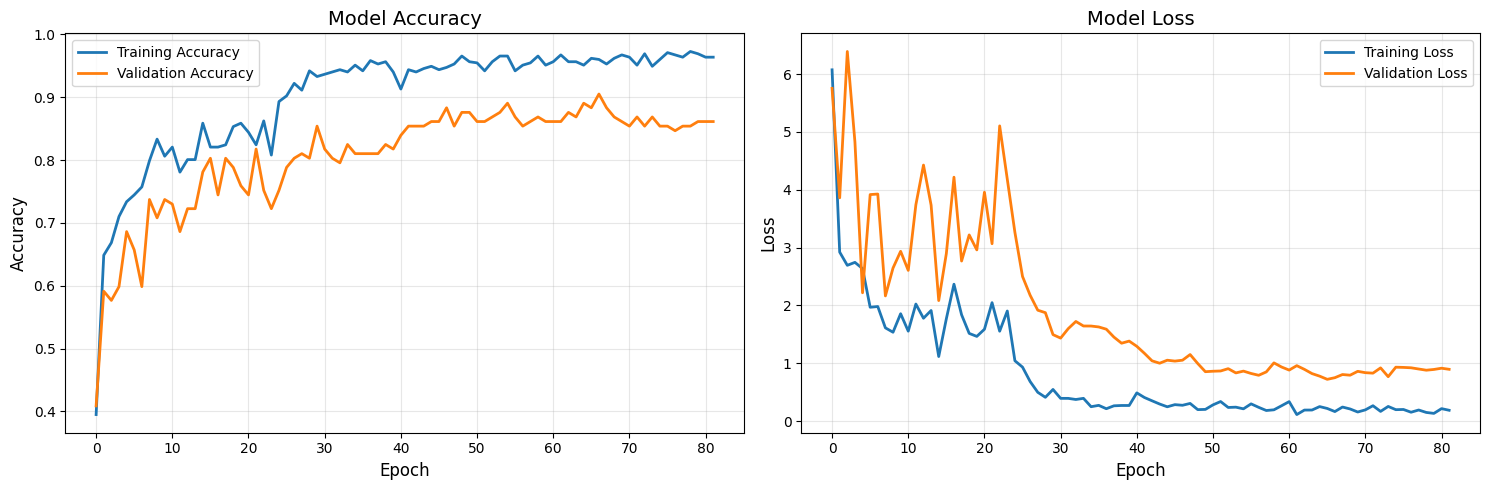

In [18]:
# MIDDLE_9

# Комбинированный Pooling + Residual connection

from tensorflow.keras.layers import GlobalAveragePooling2D, GlobalMaxPooling2D, Concatenate, Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras.regularizers import l1, l2, l1_l2

model_name = 'EfficientNetV2S' # {model_name}
alias = '_middle_9_' # {_middle_}
#val_accuracy=0



# Создание модели
import tensorflow as tf
from tensorflow.keras.applications import ResNet50, EfficientNetB0, EfficientNetV2B0, EfficientNetV2S
from tensorflow.keras import layers, Model

# Словарь моделей
MODELS = {
    'EfficientNetV2S': EfficientNetV2S,
    'EfficientNetV2B0': EfficientNetV2B0,
    'EfficientNetB0': EfficientNetB0,
    'ResNet50': ResNet50
}
'''
def dense_block(x, units, dropout_rate=0.5, l2_reg=1e-4):
    x = Dense(units, kernel_regularizer=l2(l2_reg))(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(dropout_rate)(x)
    return x
'''

# Используйте готовую функцию чтобы не думать о проекции
def residual_block(x, units, dropout_rate=0.5, l2_reg=1e-5):
    identity = x
    x = Dense(units, kernel_regularizer=l2(l2_reg))(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(dropout_rate)(x)
    
    if identity.shape[-1] != units:
        identity = Dense(units, kernel_regularizer=l2(l2_reg))(identity)
    
    return layers.Add()([identity, x])

height, width = 224, 224
#num_classes = 8  # ⬅️ ДОБАВЬТЕ ЭТУ СТРОКУ!

# 1. Сначала создаем inputs
inputs = tf.keras.Input(shape=(height, width, 3))  # ⬅️ ПЕРВЫМ ДЕЛОМ!

# 2. Базовая модель
base_model = MODELS[model_name](
    weights='imagenet',      # ✅ Предобученные веса
    include_top=False,       # ✅ Убираем старый классификатор
    input_shape=(height, width, 3)  # ⬅️ ИСПРАВЛЕНО: передаем кортеж, не переменную inputs
)
base_model.trainable = False # ✅ Замораживаем веса
x = base_model(inputs, training=False)  # ✅ BatchNorm в inference режиме

# 4. Классификатор (ваш лучший вариант)
gap = GlobalAveragePooling2D()(x)
gmp = GlobalMaxPooling2D()(x)
x = Concatenate()([gap, gmp])  # Удваиваем features
x = BatchNormalization()(x)

# Классификатор (Residual блоки вместо обычных)
#x = residual_block(x, 1024, dropout_rate=0.3, l2_reg=1e-5)
x = residual_block(x, 512, dropout_rate=0.6, l2_reg=1e-5) 
x = residual_block(x, 256, dropout_rate=0.4, l2_reg=1e-5)
#x = Dense(64, activation='relu')(x) # Финальная адаптация признаков
#x = Dropout(0.2)(x) # Минимальная регуляризация перед выходом
# 5. Выходной слой
outputs = layers.Dense(num_classes, activation='softmax')(x)

# 6. Сборка и компиляция
model = Model(inputs, outputs)
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # ✅ Для integer labels
    metrics=['accuracy']
)

print("✅ Модель создана для {} классов!".format(num_classes))
print("✅ Transfer Learning модель готова!")
print(f"🎯 {model_name} заморожена, обучаться будут только добавленные Dense слои")
model.summary()


import datetime
import os
import time
# ДОБАВЬТЕ ЭТО В САМОЕ НАЧАЛО СКРИПТА
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # 0=все, 1=INFO, 2=WARNING, 3=ERROR
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
tf.get_logger().setLevel('ERROR')
tf.autograph.set_verbosity(0)

from tensorflow.keras.callbacks import TensorBoard, EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# 2. Создаем callback
callbacks = [
    #EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True, verbose=1), # monitor='val_loss',  # ⬅️ Следим за loss (может быть стабильнее)
    ModelCheckpoint(f'./keras_lab/{model_name}/keras_{model_name}_temp.keras', monitor='val_accuracy', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', patience=9, factor=0.1, verbose=1),
    #tensorboard_callback
]

start_time = time.time()
# 4. Запускаем обучение
history = model.fit(
    train_data,
    epochs=90,
    validation_data=validation_data,
    callbacks=callbacks,
    verbose=1
)
# ВРЕМЯ
end_time = time.time()
training_time_seconds = end_time - start_time
hours = int(training_time_seconds // 3600)
minutes = int((training_time_seconds % 3600) // 60)
seconds = int(training_time_seconds % 60)
print(f"⏰ Время обучения: {hours:02d}:{minutes:02d}:{seconds:02d} (ч:м:с)")

# Оценка на валидационном датасете

best_model = tf.keras.models.load_model(f'./keras_lab/{model_name}/keras_{model_name}_temp.keras')
print(f"\n📊 ОЦЕНКА {model_name}{alias} НА ВАЛИДАЦИОННЫХ ДАННЫХ...")
val_results = best_model.evaluate(validation_data, verbose=1)
val_loss, val_accuracy = val_results

#print(f"✅ Финальная точность на валидации: {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")
#print(f"✅ Финальные потери на валидации: {val_loss:.4f}")

# Сохранение с точностью в названии
accuracy_percent = val_accuracy * 100
save_path = f'./keras_lab/{model_name}/keras_{model_name}{alias}{accuracy_percent:.2f}.keras'

best_model.save(save_path)
print(f"💾 Модель сохранена как: {save_path}")

# Визуализация результатов
import matplotlib.pyplot as plt
import numpy as np

def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # График точности
    ax1.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
    ax1.set_title('Model Accuracy', fontsize=14)
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Accuracy', fontsize=12)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # График потерь
    ax2.plot(history.history['loss'], label='Training Loss', linewidth=2)
    ax2.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    ax2.set_title('Model Loss', fontsize=14)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Loss', fontsize=12)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Построим графики
plot_training_history(history)




214201816/214201816 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step
✅ Модель создана для 33 классов!
✅ Transfer Learning модель готова!
🎯 EfficientNetV2M заморожена, обучаться будут только добавленные Dense слои


Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_22      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetv2-m    │ (None, 7, 7,      │ 53,150,388 │ input_layer_22[0… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ efficientnetv2-m… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 1280)      │          0 │ efficientnetv2-m… │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_11      │ (None, 2560)      │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 2560)      │     10,240 │ concatenate_11[0… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_76 (Dense)    │ (None, 512)       │  1,311,232 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ dense_76[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_35       │ (None, 512)       │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_77 (Dense)    │ (None, 512)       │  1,311,232 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_35          │ (None, 512)       │          0 │ activation_35[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_35 (Add)        │ (None, 512)       │          0 │ dense_77[0][0],   │
│                     │                   │            │ dropout_35[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_78 (Dense)    │ (None, 256)       │    131,328 │ add_35[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_78[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_36       │ (None, 256)       │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_79 (Dense)    │ (None, 256)       │    131,328 │ add_35[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_36          │ (None, 256)       │          0 │ activation_36[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_36 (Add)        │ (None, 256)       │          0 │ dense_79[0][0],   │
│                     │                   │            │ dropout_36[0][0]

 Total params: 56,057,301 (213.84 MB)

 Trainable params: 2,900,257 (11.06 MB)

...

34/35 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.2275 - loss: 7.9366

2025-11-06 18:08:34.146714: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-11-06 18:08:34.286606: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-11-06 18:08:34.422450: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-11-06 18:08:35.156590: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-11-06 18:08:35.320130: E external/local_xla/xla/stream_

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 781ms/step - accuracy: 0.2313 - loss: 7.9026

2025-11-06 18:09:05.052798: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-11-06 18:09:05.191222: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-11-06 18:09:05.338457: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-11-06 18:09:05.486254: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-11-06 18:09:05.628940: E external/local_xla/xla/stream_


Epoch 1: val_accuracy improved from None to 0.20438, saving model to ./keras_lab/EfficientNetV2M/keras_EfficientNetV2M_temp.keras
35/35 ━━━━━━━━━━━━━━━━━━━━ 101s 2s/step - accuracy: 0.3605 - loss: 6.7461 - val_accuracy: 0.2044 - val_loss: 11.6318 - learning_rate: 0.0010
Epoch 2/90
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.5549 - loss: 4.1495
Epoch 2: val_accuracy improved from 0.20438 to 0.32117, saving model to ./keras_lab/EfficientNetV2M/keras_EfficientNetV2M_temp.keras
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 105ms/step - accuracy: 0.5562 - loss: 4.0951 - val_accuracy: 0.3212 - val_loss: 8.2452 - learning_rate: 0.0010
Epoch 3/90
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.6148 - loss: 3.7985
Epoch 3: val_accuracy improved from 0.32117 to 0.50365, saving model to ./keras_lab/EfficientNetV2M/keras_EfficientNetV2M_temp.keras
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 106ms/step - accuracy: 0.5996 - loss: 4.0455 - val_accuracy: 0.5036 - val_loss: 2.9134 - learning_rate: 0.0010
Epoch 4/90

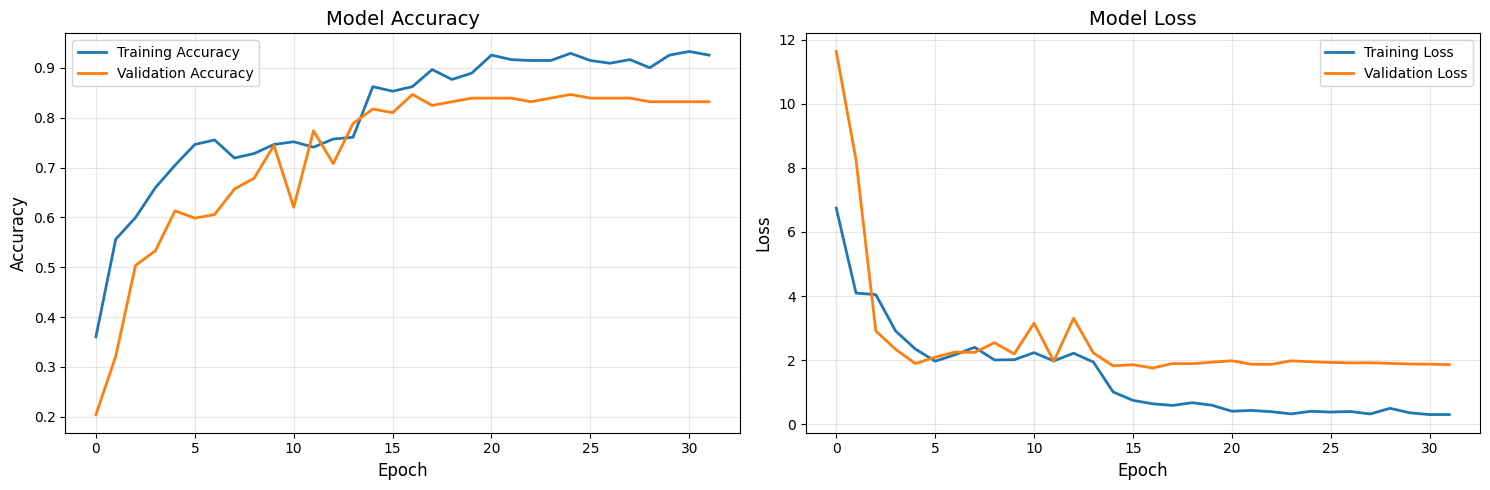

In [19]:
# MIDDLE_10

# Комбинированный Pooling + Residual connection

from tensorflow.keras.layers import GlobalAveragePooling2D, GlobalMaxPooling2D, Concatenate, Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras.regularizers import l1, l2, l1_l2

model_name = 'EfficientNetV2M' # {model_name}
alias = '_middle_10_' # {_middle_}
#val_accuracy=0



# Создание модели
import tensorflow as tf
from tensorflow.keras.applications import ResNet50, EfficientNetB0, EfficientNetV2B0, EfficientNetV2S, EfficientNetV2M, EfficientNetV2L
from tensorflow.keras import layers, Model

# Словарь моделей
MODELS = {
    'EfficientNetV2S': EfficientNetV2S,
    'EfficientNetV2M': EfficientNetV2M,
    'EfficientNetV2B0': EfficientNetV2B0,
    'EfficientNetB0': EfficientNetB0,
    
    'ResNet50': ResNet50
}
'''
def dense_block(x, units, dropout_rate=0.5, l2_reg=1e-4):
    x = Dense(units, kernel_regularizer=l2(l2_reg))(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(dropout_rate)(x)
    return x
'''

# Используйте готовую функцию чтобы не думать о проекции
def residual_block(x, units, dropout_rate=0.5, l2_reg=1e-5):
    identity = x
    x = Dense(units, kernel_regularizer=l2(l2_reg))(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(dropout_rate)(x)
    
    if identity.shape[-1] != units:
        identity = Dense(units, kernel_regularizer=l2(l2_reg))(identity)
    
    return layers.Add()([identity, x])

height, width = 224, 224
#num_classes = 8  # ⬅️ ДОБАВЬТЕ ЭТУ СТРОКУ!

# 1. Сначала создаем inputs
inputs = tf.keras.Input(shape=(height, width, 3))  # ⬅️ ПЕРВЫМ ДЕЛОМ!

# 2. Базовая модель
base_model = MODELS[model_name](
    weights='imagenet',      # ✅ Предобученные веса
    include_top=False,       # ✅ Убираем старый классификатор
    input_shape=(height, width, 3)  # ⬅️ ИСПРАВЛЕНО: передаем кортеж, не переменную inputs
)
base_model.trainable = False # ✅ Замораживаем веса
x = base_model(inputs, training=False)  # ✅ BatchNorm в inference режиме

# 4. Классификатор (ваш лучший вариант)
gap = GlobalAveragePooling2D()(x)
gmp = GlobalMaxPooling2D()(x)
x = Concatenate()([gap, gmp])  # Удваиваем features
x = BatchNormalization()(x)

# Классификатор (Residual блоки вместо обычных)
#x = residual_block(x, 1024, dropout_rate=0.3, l2_reg=1e-5)
x = residual_block(x, 512, dropout_rate=0.6, l2_reg=1e-5) 
x = residual_block(x, 256, dropout_rate=0.4, l2_reg=1e-5)
#x = Dense(64, activation='relu')(x) # Финальная адаптация признаков
#x = Dropout(0.2)(x) # Минимальная регуляризация перед выходом
# 5. Выходной слой
outputs = layers.Dense(num_classes, activation='softmax')(x)

# 6. Сборка и компиляция
model = Model(inputs, outputs)
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # ✅ Для integer labels
    metrics=['accuracy']
)

print("✅ Модель создана для {} классов!".format(num_classes))
print("✅ Transfer Learning модель готова!")
print(f"🎯 {model_name} заморожена, обучаться будут только добавленные Dense слои")
model.summary()


import datetime
import os
import time
# ДОБАВЬТЕ ЭТО В САМОЕ НАЧАЛО СКРИПТА
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # 0=все, 1=INFO, 2=WARNING, 3=ERROR
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
tf.get_logger().setLevel('ERROR')
tf.autograph.set_verbosity(0)

from tensorflow.keras.callbacks import TensorBoard, EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# 2. Создаем callback
callbacks = [
    #EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True, verbose=1), # monitor='val_loss',  # ⬅️ Следим за loss (может быть стабильнее)
    ModelCheckpoint(f'./keras_lab/{model_name}/keras_{model_name}_temp.keras', monitor='val_accuracy', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', patience=9, factor=0.1, verbose=1),
    #tensorboard_callback
]

start_time = time.time()
# 4. Запускаем обучение
history = model.fit(
    train_data,
    epochs=90,
    validation_data=validation_data,
    callbacks=callbacks,
    verbose=1
)
# ВРЕМЯ
end_time = time.time()
training_time_seconds = end_time - start_time
hours = int(training_time_seconds // 3600)
minutes = int((training_time_seconds % 3600) // 60)
seconds = int(training_time_seconds % 60)
print(f"⏰ Время обучения: {hours:02d}:{minutes:02d}:{seconds:02d} (ч:м:с)")

# Оценка на валидационном датасете

best_model = tf.keras.models.load_model(f'./keras_lab/{model_name}/keras_{model_name}_temp.keras')
print(f"\n📊 ОЦЕНКА {model_name}{alias} НА ВАЛИДАЦИОННЫХ ДАННЫХ...")
val_results = best_model.evaluate(validation_data, verbose=1)
val_loss, val_accuracy = val_results

#print(f"✅ Финальная точность на валидации: {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")
#print(f"✅ Финальные потери на валидации: {val_loss:.4f}")

# Сохранение с точностью в названии
accuracy_percent = val_accuracy * 100
save_path = f'./keras_lab/{model_name}/keras_{model_name}{alias}{accuracy_percent:.2f}.keras'

best_model.save(save_path)
print(f"💾 Модель сохранена как: {save_path}")

# Визуализация результатов
import matplotlib.pyplot as plt
import numpy as np

def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # График точности
    ax1.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
    ax1.set_title('Model Accuracy', fontsize=14)
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Accuracy', fontsize=12)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # График потерь
    ax2.plot(history.history['loss'], label='Training Loss', linewidth=2)
    ax2.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    ax2.set_title('Model Loss', fontsize=14)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Loss', fontsize=12)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Построим графики
plot_training_history(history)




✅ Модель создана для 33 классов!
✅ Transfer Learning модель готова!
🎯 EfficientNetV2M заморожена, обучаться будут только добавленные Dense слои


Model: "functional_15"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_29      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetv2-m    │ (None, 7, 7,      │ 53,150,388 │ input_layer_29[0… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ efficientnetv2-m… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 1280)      │          0 │ efficientnetv2-m… │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_14      │ (None, 2560)      │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 2560)      │     10,240 │ concatenate_14[0… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_91 (Dense)    │ (None, 512)       │  1,311,232 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ dense_91[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_41       │ (None, 512)       │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_92 (Dense)    │ (None, 512)       │  1,311,232 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_41          │ (None, 512)       │          0 │ activation_41[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_41 (Add)        │ (None, 512)       │          0 │ dense_92[0][0],   │
│                     │                   │            │ dropout_41[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_93 (Dense)    │ (None, 256)       │    131,328 │ add_41[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_93[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_42       │ (None, 256)       │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_94 (Dense)    │ (None, 256)       │    131,328 │ add_41[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_42          │ (None, 256)       │          0 │ activation_42[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_42 (Add)        │ (None, 256)       │          0 │ dense_94[0][0],   │
│                     │                   │            │ dropout_42[0][0]

 Total params: 56,058,325 (213.85 MB)

 Trainable params: 2,900,769 (11.07 MB)

 Non-trainable params: 53,157,556 (202.78 MB)

Epoch 1/90
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 713ms/step - accuracy: 0.2353 - loss: 3.2006
Epoch 1: val_accuracy improved from None to 0.29927, saving model to ./keras_lab/EfficientNetV2M/keras_EfficientNetV2M_temp.keras
35/35 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.3152 - loss: 2.6976 - val_accuracy: 0.2993 - val_loss: 3.8091 - learning_rate: 0.0010
Epoch 2/90
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.5496 - loss: 1.5583
Epoch 2: val_accuracy improved from 0.29927 to 0.44526, saving model to ./keras_lab/EfficientNetV2M/keras_EfficientNetV2M_temp.keras
35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 129ms/step - accuracy: 0.5707 - loss: 1.5365 - val_accuracy: 0.4453 - val_loss: 2.3511 - learning_rate: 0.0010
Epoch 3/90
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.6469 - loss: 1.2812
Epoch 3: val_accuracy improved from 0.44526 to 0.58394, saving model to ./keras_lab/EfficientNetV2M/keras_EfficientNetV2M_temp.keras
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 92ms/step - accuracy: 0.6594 - loss: 1

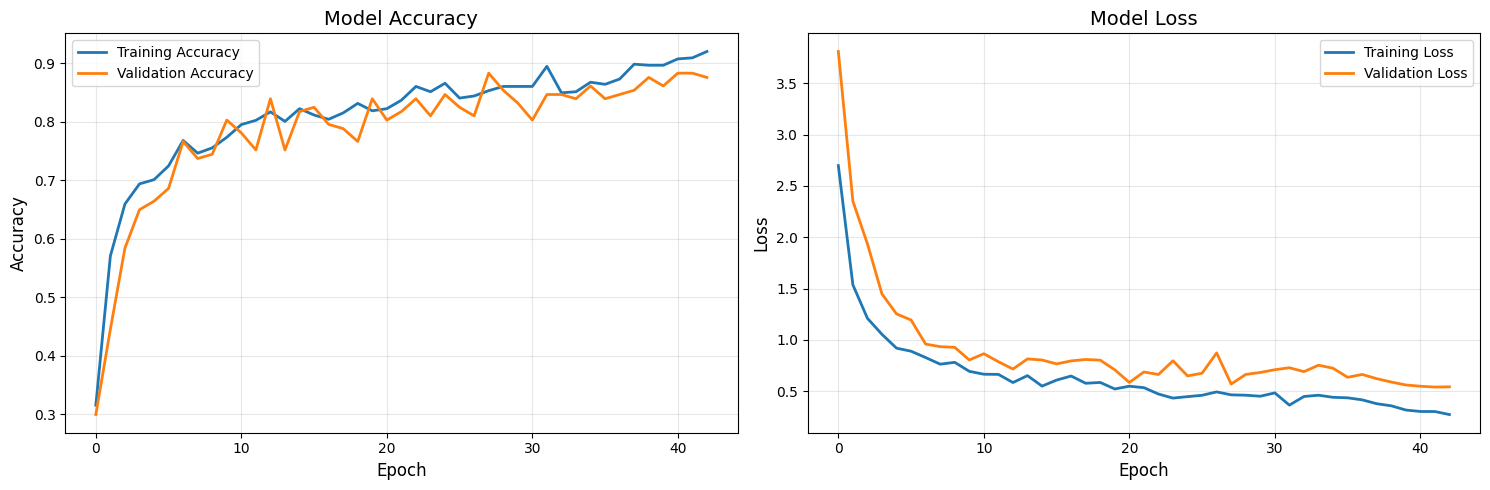

In [23]:
# MIDDLE_11

# Комбинированный Pooling + Residual connection

from tensorflow.keras.layers import GlobalAveragePooling2D, GlobalMaxPooling2D, Concatenate, Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras.regularizers import l1, l2, l1_l2

model_name = 'EfficientNetV2M' # {model_name}
alias = '_middle_11_' # {_middle_}
#val_accuracy=0



# Создание модели
import tensorflow as tf
from tensorflow.keras.applications import ResNet50, EfficientNetB0, EfficientNetV2B0, EfficientNetV2S, EfficientNetV2M, EfficientNetV2L
from tensorflow.keras import layers, Model

# Словарь моделей
MODELS = {
    'EfficientNetV2S': EfficientNetV2S,
    'EfficientNetV2M': EfficientNetV2M,
    'EfficientNetV2B0': EfficientNetV2B0,
    'EfficientNetB0': EfficientNetB0,
    
    'ResNet50': ResNet50
}
'''
def dense_block(x, units, dropout_rate=0.5, l2_reg=1e-4):
    x = Dense(units, kernel_regularizer=l2(l2_reg))(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(dropout_rate)(x)
    return x
'''

# Используйте готовую функцию чтобы не думать о проекции
def residual_block(x, units, dropout_rate=0.5, l2_reg=1e-5):
    identity = x
    x = Dense(units, kernel_regularizer=l2(l2_reg))(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(dropout_rate)(x)
    
    if identity.shape[-1] != units:
        identity = Dense(units, kernel_regularizer=l2(l2_reg))(identity)
    
    return layers.Add()([identity, x])

height, width = 224, 224
#num_classes = 8  # ⬅️ ДОБАВЬТЕ ЭТУ СТРОКУ!

# 1. Сначала создаем inputs
inputs = tf.keras.Input(shape=(height, width, 3))  # ⬅️ ПЕРВЫМ ДЕЛОМ!

# 2. Базовая модель
base_model = MODELS[model_name](
    weights='imagenet',      # ✅ Предобученные веса
    include_top=False,       # ✅ Убираем старый классификатор
    input_shape=(height, width, 3)  # ⬅️ ИСПРАВЛЕНО: передаем кортеж, не переменную inputs
)
base_model.trainable = False # ✅ Замораживаем веса
x = base_model(inputs, training=False)  # ✅ BatchNorm в inference режиме

# 4. Классификатор (ваш лучший вариант)
gap = GlobalAveragePooling2D()(x)
gmp = GlobalMaxPooling2D()(x)
x = Concatenate()([gap, gmp])  # Удваиваем features
x = BatchNormalization()(x)

# Классификатор (Residual блоки вместо обычных)
#x = residual_block(x, 1024, dropout_rate=0.3, l2_reg=1e-5)
x = residual_block(x, 512, dropout_rate=0.6, l2_reg=1e-5) 
x = residual_block(x, 256, dropout_rate=0.4, l2_reg=1e-5)
x = BatchNormalization()(x)
#x = Dense(64, activation='relu')(x) # Финальная адаптация признаков
#x = Dropout(0.2)(x) # Минимальная регуляризация перед выходом
# 5. Выходной слой
outputs = layers.Dense(num_classes, activation='softmax')(x)

# 6. Сборка и компиляция
model = Model(inputs, outputs)
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # ✅ Для integer labels
    metrics=['accuracy']
)

print("✅ Модель создана для {} классов!".format(num_classes))
print("✅ Transfer Learning модель готова!")
print(f"🎯 {model_name} заморожена, обучаться будут только добавленные Dense слои")
model.summary()


import datetime
import os
import time
# ДОБАВЬТЕ ЭТО В САМОЕ НАЧАЛО СКРИПТА
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # 0=все, 1=INFO, 2=WARNING, 3=ERROR
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
tf.get_logger().setLevel('ERROR')
tf.autograph.set_verbosity(0)

from tensorflow.keras.callbacks import TensorBoard, EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# 2. Создаем callback
callbacks = [
    #EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True, verbose=1), # monitor='val_loss',  # ⬅️ Следим за loss (может быть стабильнее)
    ModelCheckpoint(f'./keras_lab/{model_name}/keras_{model_name}_temp.keras', monitor='val_accuracy', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', patience=9, factor=0.1, verbose=1),
    #tensorboard_callback
]

start_time = time.time()
# 4. Запускаем обучение
history = model.fit(
    train_data,
    epochs=90,
    validation_data=validation_data,
    callbacks=callbacks,
    verbose=1
)
# ВРЕМЯ
end_time = time.time()
training_time_seconds = end_time - start_time
hours = int(training_time_seconds // 3600)
minutes = int((training_time_seconds % 3600) // 60)
seconds = int(training_time_seconds % 60)
print(f"⏰ Время обучения: {hours:02d}:{minutes:02d}:{seconds:02d} (ч:м:с)")

# Оценка на валидационном датасете

best_model = tf.keras.models.load_model(f'./keras_lab/{model_name}/keras_{model_name}_temp.keras')
print(f"\n📊 ОЦЕНКА {model_name}{alias} НА ВАЛИДАЦИОННЫХ ДАННЫХ...")
val_results = best_model.evaluate(validation_data, verbose=1)
val_loss, val_accuracy = val_results

#print(f"✅ Финальная точность на валидации: {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")
#print(f"✅ Финальные потери на валидации: {val_loss:.4f}")

# Сохранение с точностью в названии
accuracy_percent = val_accuracy * 100
save_path = f'./keras_lab/{model_name}/keras_{model_name}{alias}{accuracy_percent:.2f}.keras'

best_model.save(save_path)
print(f"💾 Модель сохранена как: {save_path}")

# Визуализация результатов
import matplotlib.pyplot as plt
import numpy as np

def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # График точности
    ax1.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
    ax1.set_title('Model Accuracy', fontsize=14)
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Accuracy', fontsize=12)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # График потерь
    ax2.plot(history.history['loss'], label='Training Loss', linewidth=2)
    ax2.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    ax2.set_title('Model Loss', fontsize=14)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Loss', fontsize=12)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Построим графики
plot_training_history(history)




In [ ]:
# MIDDLE_12

# Комбинированный Pooling + Residual connection

from tensorflow.keras.layers import GlobalAveragePooling2D, GlobalMaxPooling2D, Concatenate, Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras.regularizers import l1, l2, l1_l2

model_name = 'EfficientNetV2M' # {model_name}
alias = '_middle_12_' # {_middle_}
#val_accuracy=0



# Создание модели
import tensorflow as tf
from tensorflow.keras.applications import ResNet50, EfficientNetB0, EfficientNetV2B0, EfficientNetV2S, EfficientNetV2M, EfficientNetV2L
from tensorflow.keras import layers, Model

# Словарь моделей
MODELS = {
    'EfficientNetV2S': EfficientNetV2S,
    'EfficientNetV2M': EfficientNetV2M,
    'EfficientNetV2B0': EfficientNetV2B0,
    'EfficientNetB0': EfficientNetB0,
    
    'ResNet50': ResNet50
}
'''
def dense_block(x, units, dropout_rate=0.5, l2_reg=1e-4):
    x = Dense(units, kernel_regularizer=l2(l2_reg))(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(dropout_rate)(x)
    return x
'''

# Используйте готовую функцию чтобы не думать о проекции
def residual_block(x, units, dropout_rate=0.5, l2_reg=1e-5):
    identity = x
    x = Dense(units, kernel_regularizer=l2(l2_reg))(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(dropout_rate)(x)
    
    if identity.shape[-1] != units:
        identity = Dense(units, kernel_regularizer=l2(l2_reg))(identity)
    
    return layers.Add()([identity, x])

height, width = 224, 224
#num_classes = 8  # ⬅️ ДОБАВЬТЕ ЭТУ СТРОКУ!

# 1. Сначала создаем inputs
inputs = tf.keras.Input(shape=(height, width, 3))  # ⬅️ ПЕРВЫМ ДЕЛОМ!

# 2. Базовая модель
base_model = MODELS[model_name](
    weights='imagenet',      # ✅ Предобученные веса
    include_top=False,       # ✅ Убираем старый классификатор
    input_shape=(height, width, 3)  # ⬅️ ИСПРАВЛЕНО: передаем кортеж, не переменную inputs
)
base_model.trainable = False # ✅ Замораживаем веса
x = base_model(inputs, training=False)  # ✅ BatchNorm в inference режиме

# 4. Классификатор (ваш лучший вариант)
gap = GlobalAveragePooling2D()(x)
gmp = GlobalMaxPooling2D()(x)
x = Concatenate()([gap, gmp])  # Удваиваем features
x = BatchNormalization()(x)

# Классификатор (Residual блоки вместо обычных)
#x = residual_block(x, 1024, dropout_rate=0.3, l2_reg=1e-5)
x = residual_block(x, 512, dropout_rate=0.4, l2_reg=1e-5) 
x = residual_block(x, 256, dropout_rate=0.3, l2_reg=1e-5)
x = BatchNormalization()(x)
#x = Dense(64, activation='relu')(x) # Финальная адаптация признаков
#x = Dropout(0.2)(x) # Минимальная регуляризация перед выходом
# 5. Выходной слой
outputs = layers.Dense(num_classes, activation='softmax')(x)

# 6. Сборка и компиляция
model = Model(inputs, outputs)
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # ✅ Для integer labels
    metrics=['accuracy']
)

print("✅ Модель создана для {} классов!".format(num_classes))
print("✅ Transfer Learning модель готова!")
print(f"🎯 {model_name} заморожена, обучаться будут только добавленные Dense слои")
model.summary()


import datetime
import os
import time
# ДОБАВЬТЕ ЭТО В САМОЕ НАЧАЛО СКРИПТА
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # 0=все, 1=INFO, 2=WARNING, 3=ERROR
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
tf.get_logger().setLevel('ERROR')
tf.autograph.set_verbosity(0)

from tensorflow.keras.callbacks import TensorBoard, EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# 2. Создаем callback
callbacks = [
    #EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True, verbose=1), # monitor='val_loss',  # ⬅️ Следим за loss (может быть стабильнее)
    ModelCheckpoint(f'./keras_lab/{model_name}/keras_{model_name}_temp.keras', monitor='val_accuracy', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', patience=9, factor=0.1, verbose=1),
    #tensorboard_callback
]

start_time = time.time()
# 4. Запускаем обучение
history = model.fit(
    train_data,
    epochs=90,
    validation_data=validation_data,
    callbacks=callbacks,
    verbose=1
)
# ВРЕМЯ
end_time = time.time()
training_time_seconds = end_time - start_time
hours = int(training_time_seconds // 3600)
minutes = int((training_time_seconds % 3600) // 60)
seconds = int(training_time_seconds % 60)
print(f"⏰ Время обучения: {hours:02d}:{minutes:02d}:{seconds:02d} (ч:м:с)")

# Оценка на валидационном датасете

best_model = tf.keras.models.load_model(f'./keras_lab/{model_name}/keras_{model_name}_temp.keras')
print(f"\n📊 ОЦЕНКА {model_name}{alias} НА ВАЛИДАЦИОННЫХ ДАННЫХ...")
val_results = best_model.evaluate(validation_data, verbose=1)
val_loss, val_accuracy = val_results

#print(f"✅ Финальная точность на валидации: {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")
#print(f"✅ Финальные потери на валидации: {val_loss:.4f}")

# Сохранение с точностью в названии
accuracy_percent = val_accuracy * 100
save_path = f'./keras_lab/{model_name}/keras_{model_name}{alias}{accuracy_percent:.2f}.keras'

best_model.save(save_path)
print(f"💾 Модель сохранена как: {save_path}")

# Визуализация результатов
import matplotlib.pyplot as plt
import numpy as np

def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # График точности
    ax1.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
    ax1.set_title('Model Accuracy', fontsize=14)
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Accuracy', fontsize=12)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # График потерь
    ax2.plot(history.history['loss'], label='Training Loss', linewidth=2)
    ax2.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    ax2.set_title('Model Loss', fontsize=14)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Loss', fontsize=12)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Построим графики
plot_training_history(history)



✅ Модель создана для 33 классов!
✅ Transfer Learning модель готова!
🎯 EfficientNetV2M заморожена, обучаться будут только добавленные Dense слои


Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_15      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetv2-m    │ (None, 7, 7,      │ 53,150,388 │ input_layer_15[0… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ efficientnetv2-m… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 1280)      │          0 │ efficientnetv2-m… │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_7       │ (None, 2560)      │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 2560)      │     10,240 │ concatenate_7[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_35 (Dense)    │ (None, 1024)      │  2,622,464 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1024)      │      4,096 │ dense_35[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_14       │ (None, 1024)      │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_36 (Dense)    │ (None, 1024)      │  2,622,464 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_14          │ (None, 1024)      │          0 │ activation_14[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_14 (Add)        │ (None, 1024)      │          0 │ dense_36[0][0],   │
│                     │                   │            │ dropout_14[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_37 (Dense)    │ (None, 512)       │    524,800 │ add_14[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ dense_37[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_15       │ (None, 512)       │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_38 (Dense)    │ (None, 512)       │    524,800 │ add_14[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_15          │ (None, 512)       │          0 │ activation_15[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_15 (Add)        │ (None, 512)       │          0 │ dense_38[0][0],   │
│                     │                   │            │ dropout_15[0][0]

 Total params: 59,734,485 (227.87 MB)

 Trainable params: 6,574,881 (25.08 MB)

 Non-trainable params: 53,159,604 (202.79 MB)

Epoch 1/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 617ms/step - accuracy: 0.1435 - loss: 3.9233
Epoch 1: val_accuracy improved from None to 0.09489, saving model to ./keras_lab/EfficientNetV2M/keras_EfficientNetV2M_temp.keras
35/35 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step - accuracy: 0.1685 - loss: 3.3973 - val_accuracy: 0.0949 - val_loss: 5.6573 - learning_rate: 0.0010
Epoch 2/150
34/35 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.2963 - loss: 2.4604
Epoch 2: val_accuracy improved from 0.09489 to 0.21168, saving model to ./keras_lab/EfficientNetV2M/keras_EfficientNetV2M_temp.keras
35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 125ms/step - accuracy: 0.3025 - loss: 2.4051 - val_accuracy: 0.2117 - val_loss: 3.2638 - learning_rate: 0.0010
Epoch 3/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.3497 - loss: 2.1179
Epoch 3: val_accuracy improved from 0.21168 to 0.43066, saving model to ./keras_lab/EfficientNetV2M/keras_EfficientNetV2M_temp.keras
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 120ms/step - accuracy: 0.3768 - los

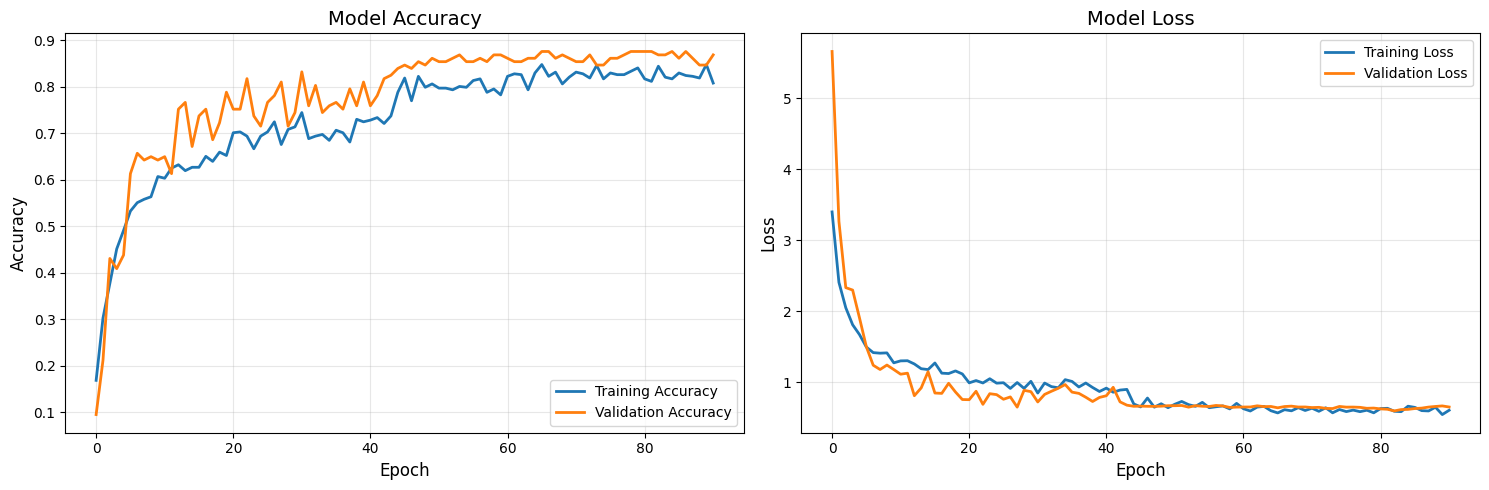

In [25]:
# MIDDLE_13

# Комбинированный Pooling + Residual connection

from tensorflow.keras.layers import GlobalAveragePooling2D, GlobalMaxPooling2D, Concatenate, Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras.regularizers import l1, l2, l1_l2

model_name = 'EfficientNetV2M' # {model_name}
alias = '_middle_13_' # {_middle_}
#val_accuracy=0



# Создание модели
import tensorflow as tf
from tensorflow.keras.applications import ResNet50, EfficientNetB0, EfficientNetV2B0, EfficientNetV2S, EfficientNetV2M, EfficientNetV2L
from tensorflow.keras import layers, Model

# Словарь моделей
MODELS = {
    'EfficientNetV2S': EfficientNetV2S,
    'EfficientNetV2M': EfficientNetV2M,
    'EfficientNetV2B0': EfficientNetV2B0,
    'EfficientNetB0': EfficientNetB0,
    
    'ResNet50': ResNet50
}
'''
def dense_block(x, units, dropout_rate=0.5, l2_reg=1e-4):
    x = Dense(units, kernel_regularizer=l2(l2_reg))(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(dropout_rate)(x)
    return x
'''

# Используйте готовую функцию чтобы не думать о проекции
def residual_block(x, units, dropout_rate=0.5, l2_reg=1e-5):
    identity = x
    x = Dense(units, kernel_regularizer=l2(l2_reg))(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(dropout_rate)(x)
    
    if identity.shape[-1] != units:
        identity = Dense(units, kernel_regularizer=l2(l2_reg))(identity)
    
    return layers.Add()([identity, x])

height, width = 224, 224
#num_classes = 8  # ⬅️ ДОБАВЬТЕ ЭТУ СТРОКУ!

# 1. Сначала создаем inputs
inputs = tf.keras.Input(shape=(height, width, 3))  # ⬅️ ПЕРВЫМ ДЕЛОМ!

# 2. Базовая модель
base_model = MODELS[model_name](
    weights='imagenet',      # ✅ Предобученные веса
    include_top=False,       # ✅ Убираем старый классификатор
    input_shape=(height, width, 3)  # ⬅️ ИСПРАВЛЕНО: передаем кортеж, не переменную inputs
)
base_model.trainable = False # ✅ Замораживаем веса
x = base_model(inputs, training=False)  # ✅ BatchNorm в inference режиме

# 4. Классификатор (ваш лучший вариант)
gap = GlobalAveragePooling2D()(x)
gmp = GlobalMaxPooling2D()(x)
x = Concatenate()([gap, gmp])  # Удваиваем features
x = BatchNormalization()(x)

# Классификатор (Residual блоки вместо обычных)
x = residual_block(x, 1024, dropout_rate=0.7, l2_reg=1e-5)
x = residual_block(x, 512, dropout_rate=0.7, l2_reg=1e-5) 
x = residual_block(x, 256, dropout_rate=0.7, l2_reg=1e-5)
x = BatchNormalization()(x)
#x = Dense(64, activation='relu')(x) # Финальная адаптация признаков
#x = Dropout(0.2)(x) # Минимальная регуляризация перед выходом
# 5. Выходной слой
outputs = layers.Dense(num_classes, activation='softmax')(x)

# 6. Сборка и компиляция
model = Model(inputs, outputs)

# Оптимизатор с weight decay
optimizer = tf.keras.optimizers.AdamW(
    learning_rate=0.001,
    weight_decay=0.0001
)

model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',  # ✅ Для integer labels
    metrics=['accuracy']
)

print("✅ Модель создана для {} классов!".format(num_classes))
print("✅ Transfer Learning модель готова!")
print(f"🎯 {model_name} заморожена, обучаться будут только добавленные Dense слои")
model.summary()


import datetime
import os
import time
# ДОБАВЬТЕ ЭТО В САМОЕ НАЧАЛО СКРИПТА
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # 0=все, 1=INFO, 2=WARNING, 3=ERROR
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
tf.get_logger().setLevel('ERROR')
tf.autograph.set_verbosity(0)

from tensorflow.keras.callbacks import TensorBoard, EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# 2. Создаем callback
callbacks = [
    #EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=25, restore_best_weights=True, verbose=1), # monitor='val_loss',  # ⬅️ Следим за loss (может быть стабильнее)
    ModelCheckpoint(f'./keras_lab/{model_name}/keras_{model_name}_temp.keras', monitor='val_accuracy', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', patience=15, factor=0.1, verbose=1),
    #tensorboard_callback
]

start_time = time.time()
# 4. Запускаем обучение
history = model.fit(
    train_data,
    epochs=150,
    validation_data=validation_data,
    callbacks=callbacks,
    verbose=1
)
# ВРЕМЯ
end_time = time.time()
training_time_seconds = end_time - start_time
hours = int(training_time_seconds // 3600)
minutes = int((training_time_seconds % 3600) // 60)
seconds = int(training_time_seconds % 60)
print(f"⏰ Время обучения: {hours:02d}:{minutes:02d}:{seconds:02d} (ч:м:с)")

# Оценка на валидационном датасете

best_model = tf.keras.models.load_model(f'./keras_lab/{model_name}/keras_{model_name}_temp.keras')
print(f"\n📊 ОЦЕНКА {model_name}{alias} НА ВАЛИДАЦИОННЫХ ДАННЫХ...")
val_results = best_model.evaluate(validation_data, verbose=1)
val_loss, val_accuracy = val_results

#print(f"✅ Финальная точность на валидации: {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")
#print(f"✅ Финальные потери на валидации: {val_loss:.4f}")

# Сохранение с точностью в названии
accuracy_percent = val_accuracy * 100
save_path = f'./keras_lab/{model_name}/keras_{model_name}{alias}{accuracy_percent:.2f}.keras'

best_model.save(save_path)
print(f"💾 Модель сохранена как: {save_path}")

# Визуализация результатов
import matplotlib.pyplot as plt
import numpy as np

def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # График точности
    ax1.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
    ax1.set_title('Model Accuracy', fontsize=14)
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Accuracy', fontsize=12)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # График потерь
    ax2.plot(history.history['loss'], label='Training Loss', linewidth=2)
    ax2.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    ax2.set_title('Model Loss', fontsize=14)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Loss', fontsize=12)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Построим графики
plot_training_history(history)



In [ ]:
height, width = 640, 480

✅ Модель создана для 33 классов!
✅ Transfer Learning модель готова!
🎯 EfficientNetV2M заморожена, обучаться будут только добавленные Dense слои


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 640, 480,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetv2-m    │ (None, 20, 15,    │ 53,150,388 │ input_layer_5[0]… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ efficientnetv2-m… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 1280)      │          0 │ efficientnetv2-m… │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 2560)      │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 2560)      │     10,240 │ concatenate[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1024)      │  2,622,464 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1024)      │      4,096 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 1024)      │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1024)      │  2,622,464 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 1024)      │          0 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1024)      │          0 │ dense_1[0][0],    │
│                     │                   │            │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 512)       │    524,800 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 512)       │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 512)       │    524,800 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 512)       │          0 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 512)       │          0 │ dense_3[0][0],    │
│                     │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 256)       │    131,328 │ add_1[0][0]     

 Total params: 59,734,485 (227.87 MB)

 Trainable params: 6,574,881 (25.08 MB)

...

34/35 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - accuracy: 0.1633 - loss: 3.7945

2025-11-06 20:19:23.159815: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-11-06 20:19:23.359140: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-11-06 20:19:23.578270: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-11-06 20:19:23.715863: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-11-06 20:19:23.856807: E external/local_xla/xla/stream_

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1648 - loss: 3.7790   

2025-11-06 20:20:09.662795: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-11-06 20:20:09.804032: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-11-06 20:20:09.940441: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-11-06 20:20:10.734934: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-11-06 20:20:10.901112: E external/local_xla/xla/stream_


Epoch 1: val_accuracy improved from None to 0.11679, saving model to ./keras_lab/EfficientNetV2M/keras_EfficientNetV2M_temp.keras
35/35 ━━━━━━━━━━━━━━━━━━━━ 129s 2s/step - accuracy: 0.2138 - loss: 3.2491 - val_accuracy: 0.1168 - val_loss: 12.0900 - learning_rate: 0.0010
Epoch 2/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.3410 - loss: 2.3190
Epoch 2: val_accuracy improved from 0.11679 to 0.18978, saving model to ./keras_lab/EfficientNetV2M/keras_EfficientNetV2M_temp.keras
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 235ms/step - accuracy: 0.3913 - loss: 2.1807 - val_accuracy: 0.1898 - val_loss: 5.0994 - learning_rate: 0.0010
Epoch 3/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 0.5326 - loss: 1.7567
Epoch 3: val_accuracy improved from 0.18978 to 0.29197, saving model to ./keras_lab/EfficientNetV2M/keras_EfficientNetV2M_temp.keras
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 227ms/step - accuracy: 0.5380 - loss: 1.7145 - val_accuracy: 0.2920 - val_loss: 4.3179 - learning_rate: 0.0010
Epoc

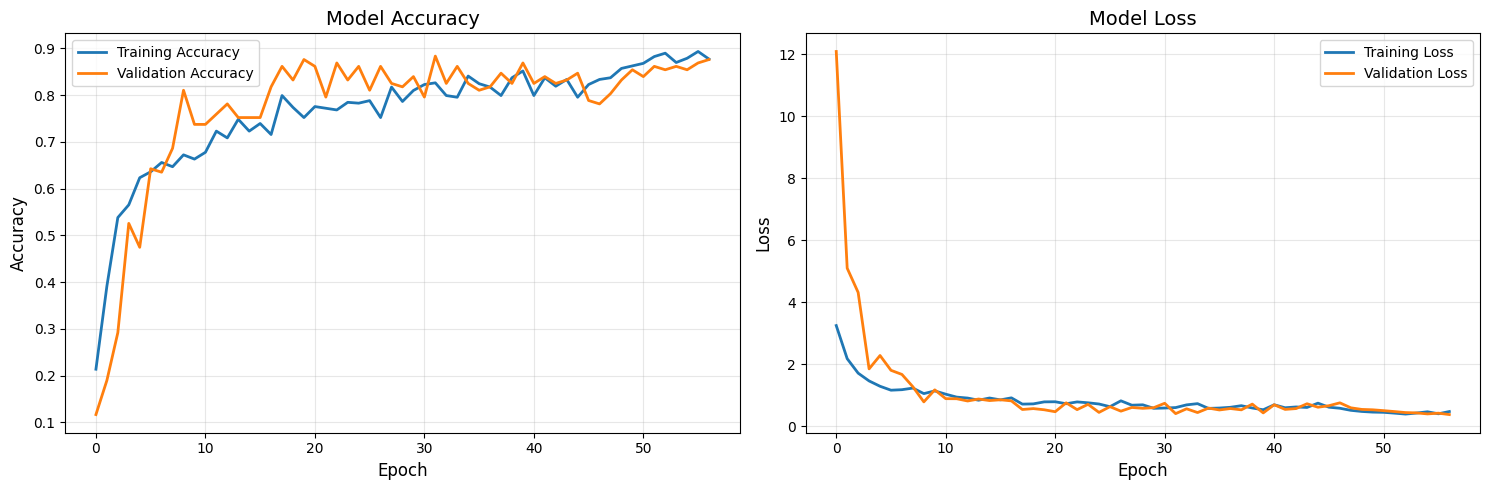

In [8]:
# MIDDLE_14

# Комбинированный Pooling + Residual connection

from tensorflow.keras.layers import GlobalAveragePooling2D, GlobalMaxPooling2D, Concatenate, Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras.regularizers import l1, l2, l1_l2

model_name = 'EfficientNetV2M' # {model_name}
alias = '_middle_14_' # {_middle_}
#val_accuracy=0



# Создание модели
import tensorflow as tf
from tensorflow.keras.applications import ResNet50, EfficientNetB0, EfficientNetV2B0, EfficientNetV2S, EfficientNetV2M, EfficientNetV2L
from tensorflow.keras import layers, Model

# Словарь моделей
MODELS = {
    'EfficientNetV2S': EfficientNetV2S,
    'EfficientNetV2M': EfficientNetV2M,
    'EfficientNetV2B0': EfficientNetV2B0,
    'EfficientNetB0': EfficientNetB0,
    
    'ResNet50': ResNet50
}
'''
def dense_block(x, units, dropout_rate=0.5, l2_reg=1e-4):
    x = Dense(units, kernel_regularizer=l2(l2_reg))(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(dropout_rate)(x)
    return x
'''

# Используйте готовую функцию чтобы не думать о проекции
def residual_block(x, units, dropout_rate=0.5, l2_reg=1e-5):
    identity = x
    x = Dense(units, kernel_regularizer=l2(l2_reg))(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(dropout_rate)(x)
    
    if identity.shape[-1] != units:
        identity = Dense(units, kernel_regularizer=l2(l2_reg))(identity)
    
    return layers.Add()([identity, x])

# height, width = 224, 224
height, width = 640, 480
#num_classes = 8  # ⬅️ ДОБАВЬТЕ ЭТУ СТРОКУ!

# 1. Сначала создаем inputs
inputs = tf.keras.Input(shape=(height, width, 3))  # ⬅️ ПЕРВЫМ ДЕЛОМ!

# 2. Базовая модель
base_model = MODELS[model_name](
    weights='imagenet',      # ✅ Предобученные веса
    include_top=False,       # ✅ Убираем старый классификатор
    input_shape=(height, width, 3)  # ⬅️ ИСПРАВЛЕНО: передаем кортеж, не переменную inputs
)
base_model.trainable = False # ✅ Замораживаем веса
x = base_model(inputs, training=False)  # ✅ BatchNorm в inference режиме

# 4. Классификатор (ваш лучший вариант)
gap = GlobalAveragePooling2D()(x)
gmp = GlobalMaxPooling2D()(x)
x = Concatenate()([gap, gmp])  # Удваиваем features
x = BatchNormalization()(x)

# Классификатор (Residual блоки вместо обычных)
x = residual_block(x, 1024, dropout_rate=0.7, l2_reg=1e-5)
x = residual_block(x, 512, dropout_rate=0.7, l2_reg=1e-5) 
x = residual_block(x, 256, dropout_rate=0.7, l2_reg=1e-5)
x = BatchNormalization()(x)
#x = Dense(64, activation='relu')(x) # Финальная адаптация признаков
x = Dropout(0.2)(x) # Минимальная регуляризация перед выходом
# 5. Выходной слой
outputs = layers.Dense(num_classes, activation='softmax')(x)

# 6. Сборка и компиляция
model = Model(inputs, outputs)

# Оптимизатор с weight decay
optimizer = tf.keras.optimizers.AdamW(
    learning_rate=0.001,
    weight_decay=0.0001
)

model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',  # ✅ Для integer labels
    metrics=['accuracy']
)

print("✅ Модель создана для {} классов!".format(num_classes))
print("✅ Transfer Learning модель готова!")
print(f"🎯 {model_name} заморожена, обучаться будут только добавленные Dense слои")
model.summary()


import datetime
import os
import time
# ДОБАВЬТЕ ЭТО В САМОЕ НАЧАЛО СКРИПТА
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # 0=все, 1=INFO, 2=WARNING, 3=ERROR
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
tf.get_logger().setLevel('ERROR')
tf.autograph.set_verbosity(0)

from tensorflow.keras.callbacks import TensorBoard, EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# 2. Создаем callback
callbacks = [
    #EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=25, restore_best_weights=True, verbose=1), # monitor='val_loss',  # ⬅️ Следим за loss (может быть стабильнее)
    ModelCheckpoint(f'./keras_lab/{model_name}/keras_{model_name}_temp.keras', monitor='val_accuracy', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', patience=15, factor=0.1, verbose=1),
    #tensorboard_callback
]

start_time = time.time()
# 4. Запускаем обучение
history = model.fit(
    train_data,
    epochs=150,
    validation_data=validation_data,
    callbacks=callbacks,
    verbose=1
)
# ВРЕМЯ
end_time = time.time()
training_time_seconds = end_time - start_time
hours = int(training_time_seconds // 3600)
minutes = int((training_time_seconds % 3600) // 60)
seconds = int(training_time_seconds % 60)
print(f"⏰ Время обучения: {hours:02d}:{minutes:02d}:{seconds:02d} (ч:м:с)")

# Оценка на валидационном датасете

best_model = tf.keras.models.load_model(f'./keras_lab/{model_name}/keras_{model_name}_temp.keras')
print(f"\n📊 ОЦЕНКА {model_name}{alias} НА ВАЛИДАЦИОННЫХ ДАННЫХ...")
val_results = best_model.evaluate(validation_data, verbose=1)
val_loss, val_accuracy = val_results

#print(f"✅ Финальная точность на валидации: {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")
#print(f"✅ Финальные потери на валидации: {val_loss:.4f}")

# Сохранение с точностью в названии
accuracy_percent = val_accuracy * 100
save_path = f'./keras_lab/{model_name}/keras_{model_name}{alias}{accuracy_percent:.2f}.keras'

best_model.save(save_path)
print(f"💾 Модель сохранена как: {save_path}")

# Визуализация результатов
import matplotlib.pyplot as plt
import numpy as np

def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # График точности
    ax1.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
    ax1.set_title('Model Accuracy', fontsize=14)
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Accuracy', fontsize=12)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # График потерь
    ax2.plot(history.history['loss'], label='Training Loss', linewidth=2)
    ax2.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    ax2.set_title('Model Loss', fontsize=14)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Loss', fontsize=12)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Построим графики
plot_training_history(history)

